
**Project title:** Interpretable multi-modal self-supervised contrastive sparse Mixture-of-Experts learning for cancer drug response prediction.


1. Leakage-safe data audit, train/validation/test split, and preprocessing fitted on training data only.
2. Multi-modal cell, drug, SMILES, RDKit, and context feature blocks with train-only SVD / SelectKBest reduction.
3. SSL backbone pretraining with optional masked autoencoder, BYOL, or SimCLR.
4. Response-aware contrastive learning for drug-response structure.
5. **True sparse top-k MoE routing**: only selected experts are evaluated per batch, reducing active compute versus dense expert evaluation.
6. **SSL embedding bottleneck reduction** before MoE fusion to reduce the representation size passed into the expert block.
7. **Mixed-precision supervised training** on GPU to reduce memory and accelerate training.
8. **AdamW + Lookahead + warmup** option for stable supervised optimization.
9. **Freeze-then-finetune SSL backbone** to reduce supervised training cost.
10. **Early-exit head** for confident/easy samples, exposing an efficiency-versus-performance trade-off.
11. **Knowledge distillation** from the best teacher MoE into a smaller student sparse MoE.
12. Expanded ablation table including SSL, CL, MoE, early-exit, optimizer, and distilled student comparisons.
13. Interpretability: feature-block occlusion, MoE routing, early-exit usage, cancer-type expert behavior, and top predicted sensitive drugs.



## Fair comparison protocol

This notebook uses a strict same-data protocol:

- All models use the same leakage-controlled rows.
- All models use the same train/validation/test split.
- All preprocessing, SVD, feature selection, and SSL pretraining are fitted using training data only.
- Hyperparameters and final architecture selection use validation performance only.
- Test labels are used once for final reporting.
- The final table reports R² as well as RMSE/MAE/Spearman so the comparison is not based on one metric only.
- Efficiency is reported through parameter count, estimated active parameter count, model size, inference time per 1,000 rows, mixed-precision usage, and early-exit rate when applicable.


In [1]:
import pandas as pd

comparison_scope = pd.DataFrame([
    {"symbol": "MM-DNN", "table": "main", "description": "Multimodal DNN with separate cell/drug/context encoders."},
    {"symbol": "TF-Fusion", "table": "main", "description": "Token-level transformer fusion over cell/drug/context representations."},
    {"symbol": "CL-DRP", "table": "main", "description": "Regression-aware contrastive baseline for drug response prediction."},
    {"symbol": "Ours-BestVal", "table": "main", "description": "Best validation-selected proposed MoE-family model."},
    {"symbol": "Ours-Ensemble", "table": "main", "description": "Validation-weighted ensemble of proposed MoE-family models."},
    {"symbol": "MLP", "table": "ablation", "description": "No SSL, no CL, no MoE."},
    {"symbol": "MoE", "table": "ablation", "description": "MoE only."},
    {"symbol": "SSL+MLP", "table": "ablation", "description": "Masked SSL only, no MoE."},
    {"symbol": "CL+MLP", "table": "ablation", "description": "Response-aware CL only, no MoE."},
    {"symbol": "SSL+MoE", "table": "ablation", "description": "Masked SSL plus MoE."},
    {"symbol": "CL+MoE", "table": "ablation/proposed candidate", "description": "Response-aware CL plus MoE."},
    {"symbol": "SSL+CL+MoE", "table": "ablation/proposed candidate", "description": "Full proposed family."},
])
display(comparison_scope)

,symbol,table,description
0,MM-DNN,main,Multimodal DNN with separate cell/drug/context...
1,TF-Fusion,main,Token-level transformer fusion over cell/drug/...
2,CL-DRP,main,Regression-aware contrastive baseline for drug...
3,Ours-BestVal,main,Best validation-selected proposed MoE-family m...
4,Ours-Ensemble,main,Validation-weighted ensemble of proposed MoE-f...
5,MLP,ablation,"No SSL, no CL, no MoE."
6,MoE,ablation,MoE only.
7,SSL+MLP,ablation,"Masked SSL only, no MoE."
8,CL+MLP,ablation,"Response-aware CL only, no MoE."
9,SSL+MoE,ablation,Masked SSL plus MoE.


## 1. Optional package setup

RDKit is kept because molecular features can improve drug representation. If RDKit cannot be installed/imported, the notebook automatically falls back to SMILES TF-IDF plus handcrafted SMILES structural features.

In [2]:
import sys
import subprocess
import importlib.util


def install_if_missing(module_name, pip_name=None):
    if pip_name is None:
        pip_name = module_name
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"{module_name} already available")

try:
    install_if_missing("pubchempy", "pubchempy")
except Exception as e:
    print("PubChemPy install failed; missing SMILES will use safe drug-name text fallback.")
    print(type(e).__name__, str(e))


def rdkit_import_works():
    try:
        from rdkit import Chem  # noqa: F401
        from rdkit.Chem import MACCSkeys, Descriptors  # noqa: F401
        from rdkit.Chem import rdFingerprintGenerator  # noqa: F401
        return True
    except Exception as e:
        print("RDKit import check failed:", type(e).__name__, str(e))
        return False

RDKIT_READY = rdkit_import_works()
if not RDKIT_READY:
    try:
        print("Trying to install RDKit with the current package name: rdkit")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "rdkit"])
        RDKIT_READY = rdkit_import_works()
    except Exception as e:
        print("RDKit install failed. Continuing without RDKit molecular descriptors.")
        print(type(e).__name__, str(e))
        RDKIT_READY = False

print("RDKIT_READY =", RDKIT_READY)

Installing pubchempy ...
RDKit import check failed: ModuleNotFoundError No module named 'rdkit'
Trying to install RDKit with the current package name: rdkit
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 50.6 MB/s eta 0:00:00
RDKIT_READY = True


## 2. Imports and configuration

The defaults are chosen for a Kaggle GPU session. For quick debugging, set `CFG.MAX_ROWS` to a smaller value and reduce `CFG.SSL_EPOCHS` / `CFG.SUP_EPOCHS`.

In [3]:
import os
import re
import math
import copy
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")


class CFG:
    SEED = 42
    TARGET = "LN_IC50"
    WORK_DIR = "/kaggle/working/gdsc_q1_final_moe_ssl_cl"
    SMILES_CACHE = "/kaggle/working/smiles_cache.csv"

    # The loader will search /kaggle/input automatically if this path is missing.
    DATA_PATH = "/kaggle/input/genomics-of-drug-sensitivity-in-cancer-gdsc/GDSC_DATASET.csv"

    MAX_ROWS = None          # e.g. 50000 for debugging; keep None for final results
    FAST_DEBUG_RUN = False    # True = smaller/shorter run only for code checking, not final results

    # Execution switches. Turn heavy options on for a final paper run after the pipeline is verified.
    RUN_CLASSICAL_BASELINES = True
    RUN_OPTIONAL_BOOSTING_BASELINES = True   # Uses LightGBM only if already installed.
    RUN_HEAVY_TREE_BASELINES = False         # Kept disabled to avoid slow RandomForest/ExtraTrees runs.
    RUN_NEURAL_BASELINES = True              # Same-data neural baselines, not a large ModelZoo.
    RUN_PROPOSED_ABLATIONS = True
    RUN_MODEL_ZOO_ENSEMBLE = False           # Disabled: final notebook focuses on proposed model + fair baselines.
    TEST_SIZE = 0.15
    VAL_SIZE = 0.15
    STRATIFIED_TARGET_SPLIT = True

    # Feature construction / reduction.
    CELL_SVD_DIM = 128
    DRUG_META_SVD_DIM = 128
    SMILES_TFIDF_MAX_FEATURES = 6000
    SMILES_NGRAM_RANGE = (2, 6)
    SMILES_SVD_DIM = 256
    MOL_SVD_DIM = 128
    CONTEXT_SVD_DIM = None
    USE_SELECT_K_BEST = True
    SELECT_K_CELL = 128
    SELECT_K_DRUG = 256
    SELECT_K_CONTEXT = 64

    # Optional train-only SMILES transformer embedding. Keep False for fast runs.
    USE_SMILES_TRANSFORMER = False
    SMILES_TRANSFORMER_DIM = 64
    SMILES_TRANSFORMER_EPOCHS = 3
    SMILES_MAX_LEN = 128

    FETCH_SMILES_FROM_PUBCHEM = True
    MAX_PUBCHEM_LOOKUPS = None  # None = all unique drugs; set integer for faster debugging
    USE_RDKIT = True
    USE_MACCS = True
    USE_RDKIT_DESCRIPTORS = True
    MORGAN_RADIUS = 2
    MORGAN_N_BITS = 1024
    MIN_VALID_RDKIT_MOLS = 10

    # Neural training.
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    BATCH_SIZE = 1024
    SCALE_TARGET = True
    LATENT_DIM = 256
    SSL_EMBED_REDUCED_DIM = 128              # Bottleneck on SSL/CL embedding before MoE fusion.
    HIDDEN_DIM = 768
    DROPOUT = 0.08
    LR = 5e-4
    WD = 2e-4
    OPTIMIZER_NAME = "adamw_lookahead"       # "adamw", "adamw_lookahead", "ranger", or "sgd_nesterov"
    OPTIMIZER_CANDIDATES = ["adamw_lookahead", "adamw"]
    USE_MIXED_PRECISION = True               # Uses FP16 autocast on CUDA only. Safely disabled on CPU.
    LR_WARMUP_EPOCHS = 3                     # Linear warmup before ReduceLROnPlateau takes over.
    SSL_METHOD = "byol"                      # "masked_ae", "byol", "simclr", or "none"
    SSL_AUG_NOISE = 0.05
    SSL_AUG_DROPOUT = 0.15
    BYOL_EMA = 0.99
    SIMCLR_TEMP = 0.15
    SSL_EPOCHS = 40
    SSL_MASK_PROB = 0.20
    SUP_EPOCHS = 50
    FREEZE_SSL_EPOCHS = 5
    PATIENCE = 8

    # Loss composition.
    NEURAL_MSE_WEIGHT = 0.70
    NEURAL_HUBER_WEIGHT = 0.30
    CL_WEIGHT_BASELINE = 0.05
    CL_WEIGHT_PROPOSED = 0.05
    CONTRASTIVE_TEMP = 0.10
    CONTRASTIVE_SIGMA = 0.50
    LB_WEIGHT = 2e-4

    # Proposed model options.
    CELL_EMB_DIM = 64
    DRUG_EMB_DIM = 64
    CANCER_EMB_DIM = 16
    PATHWAY_EMB_DIM = 24
    PAIR_INTERACTION_DIM = 64
    NUM_EXPERTS = 6
    TOP_K = 2
    ROUTER_TEMPERATURE = 0.85

    # Efficiency / novelty additions.
    USE_EARLY_EXIT = True
    EARLY_EXIT_CONF_THRESHOLD = 0.72          # Larger = fewer exits but safer predictions.
    EARLY_EXIT_LOSS_WEIGHT = 0.15
    EARLY_CONF_LOSS_WEIGHT = 0.05
    RUN_DISTILLATION = True
    # Distill the best ensemble teacher into one compact deployment model.
    # Single-teacher distillation is disabled by default to reduce redundant training time.
    RUN_SINGLE_TEACHER_DISTILLATION = False
    RUN_ENSEMBLE_DISTILLATION = True
    DISTILL_ALPHA = 0.60                     # Weight of teacher target in student regression loss.
    DISTILL_EPOCHS = 28
    ENSEMBLE_DISTILL_EPOCHS = 40
    STUDENT_LATENT_DIM = 128
    STUDENT_HIDDEN_DIM = 384
    STUDENT_NUM_EXPERTS = 4
    STUDENT_TOP_K = 1

    # Visualization only. UMAP/t-SNE is not used as model feature reduction.
    EMBED_VIS_METHOD = "pca"  # "pca", "tsne", or "umap" if installed
    MAX_VIS_POINTS = 2500

os.makedirs(CFG.WORK_DIR, exist_ok=True)


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(CFG.SEED)
print("Device:", CFG.DEVICE)
print("Work dir:", CFG.WORK_DIR)

if CFG.FAST_DEBUG_RUN:
    CFG.SSL_EPOCHS = min(CFG.SSL_EPOCHS, 5)
    CFG.SUP_EPOCHS = min(CFG.SUP_EPOCHS, 8)
    CFG.DISTILL_EPOCHS = min(CFG.DISTILL_EPOCHS, 8)
    CFG.ENSEMBLE_DISTILL_EPOCHS = min(CFG.ENSEMBLE_DISTILL_EPOCHS, 10)
    CFG.PATIENCE = min(CFG.PATIENCE, 3)
    CFG.OPTIMIZER_CANDIDATES = [CFG.OPTIMIZER_NAME]
    print("FAST_DEBUG_RUN=True: shortened epochs for code validation only.")


Device: cuda
Work dir: /kaggle/working/gdsc_q1_final_moe_ssl_cl


## 3. Load and audit the dataset

The notebook searches for `GDSC_DATASET.csv` under `/kaggle/input` if the configured path is not found.

In [4]:
def find_data_file():
    if os.path.exists(CFG.DATA_PATH):
        return CFG.DATA_PATH
    candidates = []
    for root, dirs, files in os.walk("/kaggle/input"):
        for f in files:
            if f.lower() == "gdsc_dataset.csv":
                candidates.append(os.path.join(root, f))
    if not candidates:
        for root, dirs, files in os.walk("/kaggle/input"):
            for f in files:
                if f.lower().endswith(".csv") and "gdsc" in f.lower():
                    candidates.append(os.path.join(root, f))
    if not candidates:
        raise FileNotFoundError("Could not find GDSC_DATASET.csv under /kaggle/input. Add the Kaggle dataset and rerun.")
    return candidates[0]

DATA_PATH = find_data_file()
print("Using data:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
if CFG.MAX_ROWS is not None:
    df = df.sample(CFG.MAX_ROWS, random_state=CFG.SEED).reset_index(drop=True)

print("Shape:", df.shape)
display(df.head())
print("Columns:")
print(df.columns.tolist())

Using data: /kaggle/input/datasets/samiraalipour/genomics-of-drug-sensitivity-in-cancer-gdsc/GDSC_DATASET.csv
Shape: (242035, 19)


,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication


Columns:
['COSMIC_ID', 'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME', 'LN_IC50', 'AUC', 'Z_SCORE', 'GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)', 'Microsatellite instability Status (MSI)', 'Screen Medium', 'Growth Properties', 'CNA', 'Gene Expression', 'Methylation', 'TARGET', 'TARGET_PATHWAY']


,column,dtype,missing_rate,n_unique
10,Cancer Type (matching TCGA label),object,0.212556,31
17,TARGET,object,0.112195,185
11,Microsatellite instability Status (MSI),object,0.051038,2
9,GDSC Tissue descriptor 2,object,0.038697,54
8,GDSC Tissue descriptor 1,object,0.038697,19
13,Growth Properties,object,0.038697,3
12,Screen Medium,object,0.038697,2
14,CNA,object,0.038697,2
15,Gene Expression,object,0.038697,2
16,Methylation,object,0.038697,2


count    242035.000000
mean          2.817111
std           2.762191
min          -8.747724
25%           1.508054
50%           3.236744
75%           4.700111
max          13.820189
Name: LN_IC50, dtype: float64


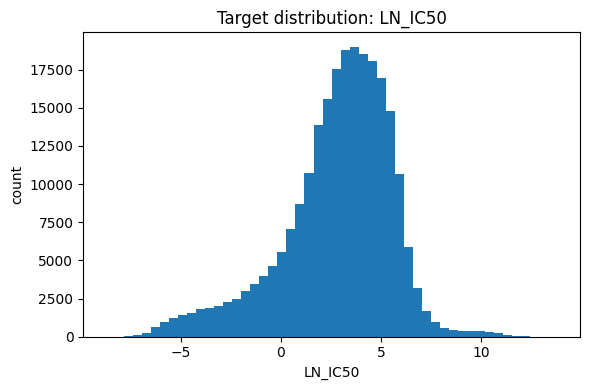

Rows belonging to duplicated CELL_LINE_NAME--DRUG_NAME pairs: 5.20%


In [5]:
# Dataset audit: missingness, target distribution, and duplicated cell-drug pairs.
assert CFG.TARGET in df.columns, f"Target {CFG.TARGET} not found. Available columns: {df.columns.tolist()}"

audit = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing_rate": [df[c].isna().mean() for c in df.columns],
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
}).sort_values(["missing_rate", "n_unique"], ascending=[False, False])
display(audit.head(25))

print(df[CFG.TARGET].describe())
plt.figure(figsize=(6, 4))
plt.hist(df[CFG.TARGET].dropna(), bins=50)
plt.title("Target distribution: LN_IC50")
plt.xlabel("LN_IC50")
plt.ylabel("count")
plt.tight_layout()
plt.show()

pair_cols = [c for c in ["CELL_LINE_NAME", "DRUG_NAME"] if c in df.columns]
if len(pair_cols) == 2:
    duplicated_pairs = df.duplicated(pair_cols, keep=False).mean()
    print(f"Rows belonging to duplicated CELL_LINE_NAME--DRUG_NAME pairs: {duplicated_pairs:.2%}")

## 4. Leakage control and feature-block definition

`AUC`, `Z_SCORE`, and curve-fit `RMSE` are removed because they summarize dose-response behavior and are too close to the target.

Pseudo-omics availability flags such as `Gene Expression`, `WES`, `CNA`, and `Methylation` are also excluded. In this merged Kaggle table, these are not full molecular matrices; they only indicate whether that omics type exists for a cell line. Treating them as real omics would be misleading.

In [6]:
df = df.dropna(subset=[CFG.TARGET]).reset_index(drop=True)

# Normalize common text fields.
for c in ["TCGA_DESC", "Cancer Type (matching TCGA label)", "PATHWAY_NAME", "TARGET_PATHWAY", "PUTATIVE_TARGET", "TARGET"]:
    if c in df.columns:
        df[c] = df[c].fillna("UNKNOWN").astype(str).replace({"nan": "UNKNOWN", "None": "UNKNOWN", "": "UNKNOWN"})

leakage_cols = [c for c in ["AUC", "Z_SCORE", "RMSE"] if c in df.columns]
pseudo_omics_flags = [c for c in ["Gene Expression", "WES", "CNA", "Methylation"] if c in df.columns]
non_predictive_ids = [c for c in ["DATASET", "NLME_RESULT_ID", "NLME_CURVE_ID", "SANGER_MODEL_ID", "COMPANY_ID", "WEBRELEASE"] if c in df.columns]

cell_cols = [c for c in [
    "COSMIC_ID", "CELL_LINE_NAME", "TCGA_DESC",
    "GDSC Tissue descriptor 1", "GDSC Tissue descriptor 2",
    "Cancer Type (matching TCGA label)",
    "Microsatellite instability Status (MSI)"
] if c in df.columns]

drug_meta_cols = [c for c in [
    "DRUG_ID", "DRUG_NAME", "PUTATIVE_TARGET", "PATHWAY_NAME",
    "TARGET", "TARGET_PATHWAY", "SYNONYMS", "SCREENING_SITE"
] if c in df.columns]

context_cols = [c for c in [
    "Screen Medium", "Growth Properties", "MIN_CONC", "MAX_CONC"
] if c in df.columns]

# Safety: remove target/leakage/pseudo-omics from feature lists if accidentally present.
remove_from_features = set([CFG.TARGET] + leakage_cols + pseudo_omics_flags + non_predictive_ids)
cell_cols = [c for c in cell_cols if c not in remove_from_features]
drug_meta_cols = [c for c in drug_meta_cols if c not in remove_from_features]
context_cols = [c for c in context_cols if c not in remove_from_features]

feature_policy = pd.DataFrame([
    {"block": "removed leakage", "columns": leakage_cols, "reason": "Directly summarizes dose-response curve or fit quality."},
    {"block": "removed pseudo-omics flags", "columns": pseudo_omics_flags, "reason": "Y/N availability indicators, not real omics matrices."},
    {"block": "removed non-predictive IDs", "columns": non_predictive_ids, "reason": "Administrative identifiers or release metadata."},
    {"block": "cell", "columns": cell_cols, "reason": "Cell-line and cancer/tissue descriptors available in this merged dataset."},
    {"block": "drug_metadata", "columns": drug_meta_cols, "reason": "Drug identity, target, and pathway descriptors."},
    {"block": "context", "columns": context_cols, "reason": "Experimental context and concentration ranges."},
])
display(feature_policy)

,block,columns,reason
0,removed leakage,"[AUC, Z_SCORE]",Directly summarizes dose-response curve or fit...
1,removed pseudo-omics flags,"[Gene Expression, CNA, Methylation]","Y/N availability indicators, not real omics ma..."
2,removed non-predictive IDs,[],Administrative identifiers or release metadata.
3,cell,"[COSMIC_ID, CELL_LINE_NAME, TCGA_DESC, GDSC Ti...",Cell-line and cancer/tissue descriptors availa...
4,drug_metadata,"[DRUG_ID, DRUG_NAME, TARGET, TARGET_PATHWAY]","Drug identity, target, and pathway descriptors."
5,context,"[Screen Medium, Growth Properties]",Experimental context and concentration ranges.


## 5. Safe SMILES and molecular features

RDKit must receive only real SMILES. If SMILES are missing, a `DRUGNAME_*` text token is allowed for TF-IDF but is never passed to RDKit.

In [7]:
try:
    import pubchempy as pcp
    PUBCHEM_AVAILABLE = True
except Exception:
    PUBCHEM_AVAILABLE = False


def clean_smiles_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none", "null", "unknown"}:
        return np.nan
    if s.startswith("DRUGNAME_"):
        return np.nan
    return s


def safe_drug_token(x):
    s = "UNKNOWN_DRUG" if pd.isna(x) else str(x)
    s = re.sub(r"[^A-Za-z0-9_\-]+", "_", s.strip())
    return "DRUGNAME_" + s[:80]

existing_smiles_cols = [c for c in df.columns if c.lower() in {"smiles", "canonical_smiles", "canonicalsmiles"}]
if existing_smiles_cols:
    smiles_col = existing_smiles_cols[0]
    df["SMILES_REAL"] = df[smiles_col].map(clean_smiles_value)
    print("Using existing SMILES column:", smiles_col)
else:
    cache = {}
    if os.path.exists(CFG.SMILES_CACHE):
        try:
            cache_df = pd.read_csv(CFG.SMILES_CACHE)
            if {"DRUG_NAME", "SMILES"}.issubset(cache_df.columns):
                cache_df["SMILES"] = cache_df["SMILES"].map(clean_smiles_value)
                cache = dict(zip(cache_df["DRUG_NAME"].astype(str), cache_df["SMILES"]))
                print("Loaded SMILES cache:", CFG.SMILES_CACHE)
        except Exception as e:
            print("Could not read SMILES cache:", e)

    unique_drugs = sorted(df["DRUG_NAME"].dropna().astype(str).unique()) if "DRUG_NAME" in df.columns else []
    if CFG.MAX_PUBCHEM_LOOKUPS is not None:
        unique_drugs = unique_drugs[:CFG.MAX_PUBCHEM_LOOKUPS]

    if CFG.FETCH_SMILES_FROM_PUBCHEM and PUBCHEM_AVAILABLE and "DRUG_NAME" in df.columns:
        for i, drug in enumerate(unique_drugs, start=1):
            if drug in cache and pd.notna(cache[drug]):
                continue
            try:
                compounds = pcp.get_compounds(drug, "name")
                cache[drug] = clean_smiles_value(compounds[0].canonical_smiles) if compounds else np.nan
            except Exception:
                cache[drug] = np.nan
            if i % 50 == 0:
                print(f"PubChem lookup {i}/{len(unique_drugs)}")
        try:
            pd.DataFrame({"DRUG_NAME": list(cache.keys()), "SMILES": list(cache.values())}).to_csv(CFG.SMILES_CACHE, index=False)
            print("Saved SMILES cache:", CFG.SMILES_CACHE)
        except Exception as e:
            print("Could not save SMILES cache:", e)

    df["SMILES_REAL"] = df["DRUG_NAME"].astype(str).map(cache).map(clean_smiles_value) if "DRUG_NAME" in df.columns else np.nan

# Text representation always exists: real SMILES if available, otherwise drug-name token.
if "DRUG_NAME" in df.columns:
    df["SMILES_TEXT"] = df["SMILES_REAL"].where(df["SMILES_REAL"].notna(), df["DRUG_NAME"].map(safe_drug_token))
else:
    df["SMILES_TEXT"] = df["SMILES_REAL"].fillna("UNKNOWN_DRUG")

df["HAS_REAL_SMILES"] = df["SMILES_REAL"].notna()
print(f"Real SMILES coverage for RDKit: {df['HAS_REAL_SMILES'].mean():.2%}")
display(df[[c for c in ["DRUG_NAME", "SMILES_REAL", "SMILES_TEXT", "HAS_REAL_SMILES"] if c in df.columns]].drop_duplicates().head(12))

PubChem lookup 50/286
PubChem lookup 100/286
PubChem lookup 150/286
PubChem lookup 200/286
PubChem lookup 250/286
Saved SMILES cache: /kaggle/working/smiles_cache.csv
Real SMILES coverage for RDKit: 82.73%


,DRUG_NAME,SMILES_REAL,SMILES_TEXT,HAS_REAL_SMILES
0,Camptothecin,CCC1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=C4C3...,CCC1(C2=C(COC1=O)C(=O)N3CC4=CC5=CC=CC=C5N=C4C3...,True
967,Vinblastine,CCC1(CC2CC(C3=C(CCN(C2)C1)C4=CC=CC=C4N3)(C5=C(...,CCC1(CC2CC(C3=C(CCN(C2)C1)C4=CC=CC=C4N3)(C5=C(...,True
1708,Cisplatin,N.N.Cl[Pt]Cl,N.N.Cl[Pt]Cl,True
2468,Cytarabine,C1=CN(C(=O)N=C1N)C2C(C(C(O2)CO)O)O,C1=CN(C(=O)N=C1N)C2C(C(C(O2)CO)O)O,True
3211,Docetaxel,CC1=C2C(C(=O)C3(C(CC4C(C3C(C(C2(C)C)(CC1OC(=O)...,CC1=C2C(C(=O)C3(C(CC4C(C3C(C(C2(C)C)(CC1OC(=O)...,True
4178,Methotrexate,CN(CC1=CN=C2C(=N1)C(=NC(=N2)N)N)C3=CC=C(C=C3)C...,CN(CC1=CN=C2C(=N1)C(=NC(=N2)N)N)C3=CC=C(C=C3)C...,True
5059,Tretinoin,CC1=C(C(CCC1)(C)C)C=CC(=CC=CC(=CC(=O)O)C)C,CC1=C(C(CCC1)(C)C)C=CC(=CC=CC(=CC(=O)O)C)C,True
5284,Gefitinib,COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OC...,COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OC...,True
6242,Navitoclax,CC1(CCC(=C(C1)CN2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(...,CC1(CCC(=C(C1)CN2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(...,True
7209,Vorinostat,C1=CC=C(C=C1)NC(=O)CCCCCCC(=O)NO,C1=CC=C(C=C1)NC(=O)CCCCCCC(=O)NO,True


## 6. Train/validation/test split

The default split is pair-level random and stratified by the `LN_IC50` distribution. This gives stable performance estimates for the merged Kaggle table. Cold-start cell/drug splits are stricter and can be added as a separate generalization experiment, but should not be mixed with this main table.

In [8]:
def make_target_bins(y, q=10):
    y = pd.Series(y).astype(float)
    try:
        bins = pd.qcut(y, q=q, duplicates="drop").cat.codes
        if len(np.unique(bins)) < 2:
            return None
        return bins
    except Exception:
        return None

stratify_all = make_target_bins(df[CFG.TARGET]) if CFG.STRATIFIED_TARGET_SPLIT else None
train_df, temp_df = train_test_split(
    df,
    test_size=CFG.TEST_SIZE + CFG.VAL_SIZE,
    random_state=CFG.SEED,
    shuffle=True,
    stratify=stratify_all,
)
relative_val = CFG.VAL_SIZE / (CFG.TEST_SIZE + CFG.VAL_SIZE)
stratify_temp = make_target_bins(temp_df[CFG.TARGET]) if CFG.STRATIFIED_TARGET_SPLIT else None
val_df, test_df = train_test_split(
    temp_df,
    test_size=1 - relative_val,
    random_state=CFG.SEED,
    shuffle=True,
    stratify=stratify_temp,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_summary = pd.DataFrame([
    {"split": "train", "n": len(train_df), "mean": train_df[CFG.TARGET].mean(), "std": train_df[CFG.TARGET].std()},
    {"split": "val", "n": len(val_df), "mean": val_df[CFG.TARGET].mean(), "std": val_df[CFG.TARGET].std()},
    {"split": "test", "n": len(test_df), "mean": test_df[CFG.TARGET].mean(), "std": test_df[CFG.TARGET].std()},
])
display(split_summary)

,split,n,mean,std
0,train,169424,2.816660,2.762822
1,val,36305,2.816755,2.762644
2,test,36306,2.819570,2.758862


## 7. Preprocessing and feature reduction

For model features, the notebook uses train-only fitted preprocessing and SVD projections. `t-SNE`/`UMAP` are reserved for visualization only because they are not stable supervised feature reducers and are not ideal for out-of-sample regression pipelines.

In [9]:
def to_dense(x):
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)


def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=5, sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=5, sparse=True)


def split_num_cat(cols, data):
    num_cols = [c for c in cols if c in data.columns and pd.api.types.is_numeric_dtype(data[c])]
    cat_cols = [c for c in cols if c in data.columns and c not in num_cols]
    return num_cols, cat_cols


def make_tabular_preprocessor(cols, fit_df, svd_dim=None, name="block"):
    if len(cols) == 0:
        return None, None, np.zeros((len(fit_df), 0), dtype="float32"), 0
    num_cols, cat_cols = split_num_cat(cols, fit_df)
    transformers = []
    if num_cols:
        transformers.append(("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False)),
        ]), num_cols))
    if cat_cols:
        transformers.append(("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols))
    pre = ColumnTransformer(transformers, sparse_threshold=1.0)
    X_raw = pre.fit_transform(fit_df[cols])
    raw_dim = X_raw.shape[1]
    print(f"{name} raw features: {raw_dim}")
    if svd_dim is not None and raw_dim > svd_dim:
        svd = TruncatedSVD(n_components=min(svd_dim, raw_dim - 1), random_state=CFG.SEED)
        X_fit = svd.fit_transform(X_raw).astype("float32")
    else:
        svd = None
        X_fit = to_dense(X_raw).astype("float32")
    return pre, svd, X_fit, raw_dim


def transform_tabular(pre, svd, data, cols):
    if pre is None or len(cols) == 0:
        return np.zeros((len(data), 0), dtype="float32")
    X = pre.transform(data[cols])
    X = svd.transform(X) if svd is not None else to_dense(X)
    return X.astype("float32")

# Cell and context blocks.
cell_pre, cell_svd, X_cell_train, cell_raw_dim = make_tabular_preprocessor(cell_cols, train_df, CFG.CELL_SVD_DIM, "cell")
X_cell_val = transform_tabular(cell_pre, cell_svd, val_df, cell_cols)
X_cell_test = transform_tabular(cell_pre, cell_svd, test_df, cell_cols)

context_pre, context_svd, X_context_train, context_raw_dim = make_tabular_preprocessor(context_cols, train_df, CFG.CONTEXT_SVD_DIM, "context")
X_context_val = transform_tabular(context_pre, context_svd, val_df, context_cols)
X_context_test = transform_tabular(context_pre, context_svd, test_df, context_cols)

# Drug metadata block.
drug_pre, drug_svd, X_drug_meta_train, drug_meta_raw_dim = make_tabular_preprocessor(drug_meta_cols, train_df, CFG.DRUG_META_SVD_DIM, "drug metadata")
X_drug_meta_val = transform_tabular(drug_pre, drug_svd, val_df, drug_meta_cols)
X_drug_meta_test = transform_tabular(drug_pre, drug_svd, test_df, drug_meta_cols)

cell raw features: 1110
context raw features: 5
drug metadata raw features: 497


In [10]:
# SMILES TF-IDF block.
smiles_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=CFG.SMILES_NGRAM_RANGE,
    max_features=CFG.SMILES_TFIDF_MAX_FEATURES,
    lowercase=False,
)
X_smiles_train_raw = smiles_vectorizer.fit_transform(train_df["SMILES_TEXT"].fillna("UNKNOWN").astype(str))
smiles_raw_dim = X_smiles_train_raw.shape[1]
smiles_svd_dim = min(CFG.SMILES_SVD_DIM, max(1, smiles_raw_dim - 1))
smiles_svd = TruncatedSVD(n_components=smiles_svd_dim, random_state=CFG.SEED)
X_smiles_train = smiles_svd.fit_transform(X_smiles_train_raw).astype("float32")

def transform_smiles(data):
    X_raw = smiles_vectorizer.transform(data["SMILES_TEXT"].fillna("UNKNOWN").astype(str))
    return smiles_svd.transform(X_raw).astype("float32")

X_smiles_val = transform_smiles(val_df)
X_smiles_test = transform_smiles(test_df)
print("SMILES TF-IDF raw features:", smiles_raw_dim, "->", X_smiles_train.shape[1])

# Low-dimensional handcrafted SMILES structural features.
SMILES_STRUCT_FEATURE_NAMES = [
    "smiles_len", "count_C", "count_N", "count_O", "count_S", "count_P",
    "count_F", "count_Cl", "count_Br", "count_I", "count_aromatic_lowercase",
    "count_digits", "count_branch_open", "count_branch_close",
    "count_double_bonds", "count_triple_bonds", "count_plus", "count_minus",
    "count_bracket_open", "count_bracket_close", "count_slash", "count_backslash",
    "hetero_ratio", "ring_ratio", "branch_ratio", "aromatic_ratio",
]


def smiles_struct_features(smiles_values):
    rows = []
    for smi in pd.Series(smiles_values).fillna("").astype(str):
        s = smi.strip()
        L = max(len(s), 1)
        count_C = s.count("C") + s.count("c")
        count_N = s.count("N") + s.count("n")
        count_O = s.count("O") + s.count("o")
        count_S = s.count("S") + s.count("s")
        count_P = s.count("P") + s.count("p")
        count_F = s.count("F")
        count_Cl = s.count("Cl")
        count_Br = s.count("Br")
        count_I = s.count("I")
        count_aromatic = sum(ch in "bcnops" for ch in s)
        count_digits = sum(ch.isdigit() for ch in s)
        count_branch_open = s.count("(")
        count_branch_close = s.count(")")
        count_double = s.count("=")
        count_triple = s.count("#")
        count_plus = s.count("+")
        count_minus = s.count("-")
        count_bo = s.count("[")
        count_bc = s.count("]")
        count_slash = s.count("/")
        count_backslash = s.count("\\")
        hetero = count_N + count_O + count_S + count_P + count_F + count_Cl + count_Br + count_I
        rows.append([
            L, count_C, count_N, count_O, count_S, count_P,
            count_F, count_Cl, count_Br, count_I, count_aromatic,
            count_digits, count_branch_open, count_branch_close,
            count_double, count_triple, count_plus, count_minus,
            count_bo, count_bc, count_slash, count_backslash,
            hetero / L, count_digits / L, (count_branch_open + count_branch_close) / L, count_aromatic / L,
        ])
    return np.nan_to_num(np.asarray(rows, dtype="float32"), nan=0.0, posinf=0.0, neginf=0.0)

struct_scaler = StandardScaler()
X_struct_train = struct_scaler.fit_transform(smiles_struct_features(train_df["SMILES_REAL"])).astype("float32")
X_struct_val = struct_scaler.transform(smiles_struct_features(val_df["SMILES_REAL"])).astype("float32")
X_struct_test = struct_scaler.transform(smiles_struct_features(test_df["SMILES_REAL"])).astype("float32")
print("Handcrafted SMILES structural features:", X_struct_train.shape[1])

SMILES TF-IDF raw features: 6000 -> 256
Handcrafted SMILES structural features: 26


In [11]:
# Optional RDKit molecular fingerprints/descriptors.
MOL_DESCRIPTOR_NAMES = []
for _name in [
    "MolWt", "MolLogP", "TPSA", "NumHDonors", "NumHAcceptors", "NumRotatableBonds",
    "RingCount", "HeavyAtomCount", "NHOHCount", "NOCount", "FractionCSP3",
    "NumAromaticRings", "NumSaturatedRings", "NumAliphaticRings", "LabuteASA",
    "BalabanJ", "BertzCT", "Chi0", "Chi1", "Kappa1", "Kappa2", "Kappa3"
]:
    MOL_DESCRIPTOR_NAMES.append(_name)

mol_scaler = None
mol_svd = None
mol_raw_dim = 0


def build_rdkit_matrix(data):
    if not (CFG.USE_RDKIT and RDKIT_READY):
        return np.zeros((len(data), 0), dtype="float32")
    from rdkit import Chem, RDLogger
    from rdkit.Chem import MACCSkeys, Descriptors, rdFingerprintGenerator
    RDLogger.DisableLog("rdApp.*")
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=CFG.MORGAN_RADIUS, fpSize=CFG.MORGAN_N_BITS)
    rows = []
    valid = 0
    for smi in data["SMILES_REAL"].values:
        mol = Chem.MolFromSmiles(str(smi)) if pd.notna(smi) else None
        if mol is None:
            rows.append(None)
            continue
        valid += 1
        feats = []
        feats.extend(list(generator.GetFingerprint(mol).ToBitString()))
        if CFG.USE_MACCS:
            feats.extend(list(MACCSkeys.GenMACCSKeys(mol).ToBitString()))
        if CFG.USE_RDKIT_DESCRIPTORS:
            for name in MOL_DESCRIPTOR_NAMES:
                try:
                    feats.append(float(getattr(Descriptors, name)(mol)))
                except Exception:
                    feats.append(0.0)
        rows.append(feats)
    if valid < CFG.MIN_VALID_RDKIT_MOLS:
        print(f"Valid RDKit molecules only {valid}; skipping RDKit matrix.")
        return np.zeros((len(data), 0), dtype="float32")
    width = max(len(r) for r in rows if r is not None)
    X = np.zeros((len(rows), width), dtype="float32")
    for i, r in enumerate(rows):
        if r is not None:
            X[i, :len(r)] = np.asarray(r, dtype="float32")
    return np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

X_mol_train_raw = build_rdkit_matrix(train_df)
mol_raw_dim = X_mol_train_raw.shape[1]
if mol_raw_dim > 0:
    mol_scaler = StandardScaler(with_mean=False)
    X_mol_train_scaled = mol_scaler.fit_transform(X_mol_train_raw)
    if mol_raw_dim > CFG.MOL_SVD_DIM:
        mol_svd = TruncatedSVD(n_components=min(CFG.MOL_SVD_DIM, mol_raw_dim - 1), random_state=CFG.SEED)
        X_mol_train = mol_svd.fit_transform(X_mol_train_scaled).astype("float32")
    else:
        X_mol_train = to_dense(X_mol_train_scaled).astype("float32")
else:
    X_mol_train = np.zeros((len(train_df), 0), dtype="float32")


def transform_mol(data):
    if mol_raw_dim == 0:
        return np.zeros((len(data), 0), dtype="float32")
    X_raw = build_rdkit_matrix(data)
    X_scaled = mol_scaler.transform(X_raw)
    X = mol_svd.transform(X_scaled) if mol_svd is not None else to_dense(X_scaled)
    return X.astype("float32")

X_mol_val = transform_mol(val_df)
X_mol_test = transform_mol(test_df)
print("RDKit molecular features:", mol_raw_dim, "->", X_mol_train.shape[1])

RDKit molecular features: 1213 -> 128


### Optional SMILES transformer embeddings

This optional block learns a compact character-transformer representation from training SMILES only. It is disabled by default for speed and automatically returns an empty block when disabled.


In [12]:
class SmilesCharDataset(Dataset):
    def __init__(self, texts, vocab, max_len):
        self.texts = list(texts)
        self.vocab = vocab
        self.max_len = max_len
        self.pad_id = vocab["<PAD>"]
        self.mask_id = vocab["<MASK>"]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        s = str(self.texts[idx])[:self.max_len]
        ids = [self.vocab.get(ch, self.vocab["<UNK>"]) for ch in s]
        ids = ids + [self.pad_id] * (self.max_len - len(ids))
        return torch.tensor(ids, dtype=torch.long)


class TinySmilesTransformer(nn.Module):
    def __init__(self, vocab_size, dim=64, heads=4, layers=2, max_len=128):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, dim, padding_idx=0)
        self.pos_emb = nn.Parameter(torch.zeros(1, max_len, dim))
        layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=heads, dim_feedforward=dim * 4,
            dropout=0.10, batch_first=True, activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=layers)
        self.recon = nn.Linear(dim, vocab_size)

    def forward(self, ids):
        pad = ids.eq(0)
        x = self.token_emb(ids) + self.pos_emb[:, :ids.shape[1], :]
        h = self.encoder(x, src_key_padding_mask=pad)
        logits = self.recon(h)
        denom = (~pad).sum(dim=1).clamp_min(1).unsqueeze(1)
        pooled = (h * (~pad).unsqueeze(-1)).sum(dim=1) / denom
        return logits, pooled


def train_optional_smiles_transformer(train_texts, val_texts, test_texts):
    chars = sorted(set("".join(map(str, train_texts))))
    vocab = {"<PAD>": 0, "<UNK>": 1, "<MASK>": 2}
    vocab.update({ch: i + 3 for i, ch in enumerate(chars)})

    model = TinySmilesTransformer(
        vocab_size=len(vocab),
        dim=CFG.SMILES_TRANSFORMER_DIM,
        max_len=CFG.SMILES_MAX_LEN,
    ).to(CFG.DEVICE)
    loader = DataLoader(
        SmilesCharDataset(train_texts, vocab, CFG.SMILES_MAX_LEN),
        batch_size=CFG.BATCH_SIZE,
        shuffle=True,
        pin_memory=(CFG.DEVICE == "cuda"),
    )
    opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

    for epoch in range(1, CFG.SMILES_TRANSFORMER_EPOCHS + 1):
        model.train()
        losses = []
        for ids in loader:
            ids = ids.to(CFG.DEVICE)
            masked = ids.clone()
            valid = ~ids.eq(vocab["<PAD>"])
            mask_pos = (torch.rand_like(ids.float()) < 0.15) & valid
            masked[mask_pos] = vocab["<MASK>"]
            logits, _ = model(masked)
            loss = F.cross_entropy(logits.view(-1, logits.shape[-1]), ids.view(-1), ignore_index=vocab["<PAD>"])
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(float(loss.detach().cpu()))
        print(f"SMILES transformer epoch {epoch:02d} | loss {np.mean(losses):.4f}")

    @torch.no_grad()
    def encode(texts):
        model.eval()
        loader_eval = DataLoader(
            SmilesCharDataset(texts, vocab, CFG.SMILES_MAX_LEN),
            batch_size=CFG.BATCH_SIZE,
            shuffle=False,
            pin_memory=(CFG.DEVICE == "cuda"),
        )
        vectors = []
        for ids in loader_eval:
            ids = ids.to(CFG.DEVICE)
            _, pooled = model(ids)
            vectors.append(pooled.detach().cpu().numpy())
        return np.vstack(vectors).astype("float32")

    return encode(train_texts), encode(val_texts), encode(test_texts)


if getattr(CFG, "USE_SMILES_TRANSFORMER", False):
    X_smiles_transformer_train, X_smiles_transformer_val, X_smiles_transformer_test = train_optional_smiles_transformer(
        train_df["SMILES_TEXT"].fillna("UNKNOWN").astype(str),
        val_df["SMILES_TEXT"].fillna("UNKNOWN").astype(str),
        test_df["SMILES_TEXT"].fillna("UNKNOWN").astype(str),
    )
else:
    X_smiles_transformer_train = np.zeros((len(train_df), 0), dtype="float32")
    X_smiles_transformer_val = np.zeros((len(val_df), 0), dtype="float32")
    X_smiles_transformer_test = np.zeros((len(test_df), 0), dtype="float32")

print("SMILES transformer feature dim:", X_smiles_transformer_train.shape[1])


SMILES transformer feature dim: 0


In [13]:
# ----------------------------
# 1. Extract targets first
y_train = train_df[CFG.TARGET].values.astype("float32")
y_val = val_df[CFG.TARGET].values.astype("float32")
y_test = test_df[CFG.TARGET].values.astype("float32")
Y_MEAN = float(y_train.mean())
Y_STD = float(y_train.std() + 1e-8)

def scale_y(y):
    return ((np.asarray(y).astype("float32") - Y_MEAN) / Y_STD).astype("float32") if CFG.SCALE_TARGET else np.asarray(y).astype("float32")

def inv_y(y):
    y = np.asarray(y).astype("float32")
    return y * Y_STD + Y_MEAN if CFG.SCALE_TARGET else y

y_train_model = scale_y(y_train)
y_val_model = scale_y(y_val)
y_test_model = scale_y(y_test)

# ----------------------------
# 2. Combine drug representation and keep feature slices for interpretability
drug_slices = {}
start = 0
parts_train, parts_val, parts_test = [], [], []

for name, A_tr, A_va, A_te in [
    ("drug_meta", X_drug_meta_train, X_drug_meta_val, X_drug_meta_test),
    ("smiles_tfidf", X_smiles_train, X_smiles_val, X_smiles_test),
    ("smiles_struct", X_struct_train, X_struct_val, X_struct_test),
    ("rdkit_molecular", X_mol_train, X_mol_val, X_mol_test),
    ("smiles_transformer", X_smiles_transformer_train, X_smiles_transformer_val, X_smiles_transformer_test),
]:
    parts_train.append(A_tr)
    parts_val.append(A_va)
    parts_test.append(A_te)
    drug_slices[name] = (start, start + A_tr.shape[1])
    start += A_tr.shape[1]

X_drug_train = np.concatenate(parts_train, axis=1).astype("float32")
X_drug_val = np.concatenate(parts_val, axis=1).astype("float32")
X_drug_test = np.concatenate(parts_test, axis=1).astype("float32")

# ----------------------------
# 3. Optional feature selection
drug_selector = None
if getattr(CFG, "USE_SELECT_K_BEST", False) and X_drug_train.shape[1] > getattr(CFG, "SELECT_K_DRUG", X_drug_train.shape[1]):
    drug_selector = SelectKBest(score_func=f_regression, k=min(CFG.SELECT_K_DRUG, X_drug_train.shape[1]))
    X_drug_train = drug_selector.fit_transform(X_drug_train, y_train).astype("float32")
    X_drug_val = drug_selector.transform(X_drug_val).astype("float32")
    X_drug_test = drug_selector.transform(X_drug_test).astype("float32")
    print("Applied SelectKBest to drug block:", X_drug_train.shape[1])

# ----------------------------
# 4. Preprocess cell and context features
X_cell_train = np.nan_to_num(X_cell_train, nan=0.0, posinf=0.0, neginf=0.0).astype("float32")
X_cell_val = np.nan_to_num(X_cell_val, nan=0.0, posinf=0.0, neginf=0.0).astype("float32")
X_cell_test = np.nan_to_num(X_cell_test, nan=0.0, posinf=0.0, neginf=0.0).astype("float32")

X_context_train = np.nan_to_num(X_context_train, nan=0.0, posinf=0.0, neginf=0.0).astype("float32")
X_context_val = np.nan_to_num(X_context_val, nan=0.0, posinf=0.0, neginf=0.0).astype("float32")
X_context_test = np.nan_to_num(X_context_test, nan=0.0, posinf=0.0, neginf=0.0).astype("float32")

# ----------------------------
# 5. Compute total feature dimensions
CELL_DIM = X_cell_train.shape[1]
DRUG_DIM = X_drug_train.shape[1]
CONTEXT_DIM = X_context_train.shape[1]
TOTAL_DIM = CELL_DIM + DRUG_DIM + CONTEXT_DIM

# ----------------------------
# 6. Feature reduction summary for interpretability
feature_reduction_summary = pd.DataFrame([
    {"block": "cell", "raw_features": cell_raw_dim, "final_features": CELL_DIM, "method": "OHE/numeric + SVD if high-dimensional"},
    {"block": "drug_metadata", "raw_features": drug_meta_raw_dim, "final_features": X_drug_meta_train.shape[1], "method": "OHE/numeric + SVD"},
    {"block": "SMILES_TFIDF", "raw_features": smiles_raw_dim, "final_features": X_smiles_train.shape[1], "method": "character n-gram TF-IDF + SVD"},
    {"block": "SMILES_struct", "raw_features": X_struct_train.shape[1], "final_features": X_struct_train.shape[1], "method": "handcrafted structural counts/ratios + scaler"},
    {"block": "RDKit_molecular", "raw_features": mol_raw_dim, "final_features": X_mol_train.shape[1], "method": "Morgan/MACCS/descriptors + scaler + SVD"},
    {"block": "context", "raw_features": context_raw_dim, "final_features": CONTEXT_DIM, "method": "OHE/numeric preprocessing"},
    {"block": "ssl_embedding_bottleneck", "raw_features": CFG.LATENT_DIM, "final_features": min(CFG.SSL_EMBED_REDUCED_DIM, CFG.LATENT_DIM), "method": "trainable bottleneck before MoE / CL fusion"},
    {"block": "total", "raw_features": None, "final_features": TOTAL_DIM, "method": "cell + drug + context"},
])
display(feature_reduction_summary)

print("Shapes:", X_cell_train.shape, X_drug_train.shape, X_context_train.shape, "target", y_train.shape)
print("Drug slices:", drug_slices)

Applied SelectKBest to drug block: 256


,block,raw_features,final_features,method
0,cell,1110.0,128,OHE/numeric + SVD if high-dimensional
1,drug_metadata,497.0,128,OHE/numeric + SVD
2,SMILES_TFIDF,6000.0,256,character n-gram TF-IDF + SVD
3,SMILES_struct,26.0,26,handcrafted structural counts/ratios + scaler
4,RDKit_molecular,1213.0,128,Morgan/MACCS/descriptors + scaler + SVD
5,context,5.0,5,OHE/numeric preprocessing
6,ssl_embedding_bottleneck,256.0,128,trainable bottleneck before MoE / CL fusion
7,total,NaN,389,cell + drug + context


Shapes: (169424, 128) (169424, 256) (169424, 5) target (169424,)
Drug slices: {'drug_meta': (0, 128), 'smiles_tfidf': (128, 384), 'smiles_struct': (384, 410), 'rdkit_molecular': (410, 538), 'smiles_transformer': (538, 538)}


## 8. Datasets, entity IDs, and evaluation metrics

Entity IDs are used only inside the proposed model family to capture explicit cell-line × drug interactions. They do not introduce external data.

In [14]:
def pick_col(data, candidates):
    for c in candidates:
        if c in data.columns:
            return c
    return None

ENTITY_COLS = {
    "cell_id": pick_col(df, ["CELL_LINE_NAME", "COSMIC_ID"]),
    "drug_id": pick_col(df, ["DRUG_NAME", "DRUG_ID"]),
    "cancer_id": pick_col(df, ["TCGA_DESC", "Cancer Type (matching TCGA label)"]),
    "pathway_id": pick_col(df, ["PATHWAY_NAME", "TARGET_PATHWAY"]),
}
print("Entity source columns:", ENTITY_COLS)

entity_maps = {}
for key, col in ENTITY_COLS.items():
    if col is None:
        entity_maps[key] = {"<UNK>": 0}
    else:
        vals = train_df[col].fillna("<UNK>").astype(str).unique().tolist()
        entity_maps[key] = {"<UNK>": 0, **{v: i + 1 for i, v in enumerate(sorted(vals))}}
entity_cardinalities = {k: len(v) for k, v in entity_maps.items()}
print("Entity cardinalities:", entity_cardinalities)


def encode_entities(data):
    out = {}
    for key, col in ENTITY_COLS.items():
        if col is None:
            out[key] = np.zeros(len(data), dtype="int64")
        else:
            m = entity_maps[key]
            out[key] = data[col].fillna("<UNK>").astype(str).map(lambda x: m.get(x, 0)).values.astype("int64")
    return out

train_entities = encode_entities(train_df)
val_entities = encode_entities(val_df)
test_entities = encode_entities(test_df)


class GDSCDataset(Dataset):
    def __init__(self, X_cell, X_drug, X_context, y, entities=None):
        self.cell = torch.tensor(X_cell, dtype=torch.float32)
        self.drug = torch.tensor(X_drug, dtype=torch.float32)
        self.context = torch.tensor(X_context, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.entities = entities or {}
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        item = {"cell": self.cell[idx], "drug": self.drug[idx], "context": self.context[idx], "y": self.y[idx]}
        for key, arr in self.entities.items():
            item[f"entity_{key}"] = torch.tensor(arr[idx], dtype=torch.long)
        return item


def make_loader(Xc, Xd, Xctx, y, entities, shuffle=False, batch_size=None):
    return DataLoader(
        GDSCDataset(Xc, Xd, Xctx, y, entities),
        batch_size=batch_size or CFG.BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(CFG.DEVICE == "cuda"),
    )

train_loader = make_loader(X_cell_train, X_drug_train, X_context_train, y_train_model, train_entities, shuffle=True)
val_loader = make_loader(X_cell_val, X_drug_val, X_context_val, y_val_model, val_entities, shuffle=False)
test_loader = make_loader(X_cell_test, X_drug_test, X_context_test, y_test_model, test_entities, shuffle=False)

Entity source columns: {'cell_id': 'CELL_LINE_NAME', 'drug_id': 'DRUG_NAME', 'cancer_id': 'TCGA_DESC', 'pathway_id': 'TARGET_PATHWAY'}
Entity cardinalities: {'cell_id': 970, 'drug_id': 287, 'cancer_id': 34, 'pathway_id': 25}


In [15]:
from sklearn.metrics import median_absolute_error, explained_variance_score


def regression_metrics(y_true, y_pred):
    """Regression metrics for LN_IC50 prediction.

    Lower LN_IC50 means higher sensitivity, so ranking metrics and top-k hit rate are useful
    alongside RMSE/R2. MAPE is intentionally omitted because LN_IC50 can be zero/negative.
    """
    y_true = np.asarray(y_true).ravel().astype(float)
    y_pred = np.asarray(y_pred).ravel().astype(float)
    err = y_pred - y_true
    abs_err = np.abs(err)
    mse = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(y_true, y_pred))
    medae = float(median_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    evs = float(explained_variance_score(y_true, y_pred))
    y_range = float(np.max(y_true) - np.min(y_true) + 1e-8)
    y_std = float(np.std(y_true) + 1e-8)
    y_iqr = float(np.subtract(*np.percentile(y_true, [75, 25])) + 1e-8)
    norm_rmse = float(rmse / y_std)
    iqr_rmse = float(rmse / y_iqr)
    rrmse = float(rmse / y_range)
    pearson = float(pearsonr(y_true, y_pred)[0]) if len(np.unique(y_true)) > 1 and len(np.unique(y_pred)) > 1 else np.nan
    spearman = float(spearmanr(y_true, y_pred)[0]) if len(np.unique(y_true)) > 1 and len(np.unique(y_pred)) > 1 else np.nan
    # Willmott index and Lin-like concordance coefficient.
    denom = np.sum((np.abs(y_pred - y_true.mean()) + np.abs(y_true - y_true.mean())) ** 2) + 1e-8
    wi = float(1.0 - np.sum((y_pred - y_true) ** 2) / denom)
    cov = float(np.mean((y_true - y_true.mean()) * (y_pred - y_pred.mean())))
    lmc = float((2 * cov) / (np.var(y_true) + np.var(y_pred) + (y_true.mean() - y_pred.mean()) ** 2 + 1e-8))
    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "medae": medae,
        "p90_abs_error": float(np.percentile(abs_err, 90)),
        "bias_mean_error": float(np.mean(err)),
        "error_std": float(np.std(err)),
        "r2": r2,
        "explained_variance": evs,
        "norm_rmse": norm_rmse,
        "iqr_rmse": iqr_rmse,
        "rrmse": rrmse,
        "pearson": pearson,
        "spearman": spearman,
        "wi": wi,
        "lmc": lmc,
    }


def group_spearman(eval_df, group_col="CELL_LINE_NAME", min_n=8):
    if group_col not in eval_df.columns:
        return np.nan
    vals = []
    for _, g in eval_df.groupby(group_col):
        if len(g) >= min_n and g["true"].nunique() > 1 and g["pred"].nunique() > 1:
            vals.append(spearmanr(g["true"], g["pred"])[0])
    return float(np.nanmean(vals)) if vals else np.nan


def topk_drug_hit_rate(eval_df, k=3):
    """For each cell line, compare the predicted top-sensitive drugs with true top-sensitive drugs.

    Because lower LN_IC50 means stronger sensitivity, top-k uses nsmallest().
    """
    if not {"CELL_LINE_NAME", "DRUG_NAME", "true", "pred"}.issubset(eval_df.columns):
        return {f"top{k}_drug_hit": np.nan}
    hits, total = 0.0, 0
    for _, g in eval_df.groupby("CELL_LINE_NAME"):
        if len(g) < k:
            continue
        true_top = set(g.nsmallest(k, "true")["DRUG_NAME"])
        pred_top = set(g.nsmallest(k, "pred")["DRUG_NAME"])
        hits += len(true_top & pred_top) / k
        total += 1
    return {f"top{k}_drug_hit": float(hits / total) if total else np.nan}


def extended_metrics(df_part, y_true, y_pred):
    metrics = regression_metrics(y_true, y_pred)
    eval_df = df_part.copy().reset_index(drop=True)
    eval_df["true"] = np.asarray(y_true).ravel()
    eval_df["pred"] = np.asarray(y_pred).ravel()
    metrics["cell_spearman"] = group_spearman(eval_df, "CELL_LINE_NAME")
    metrics.update(topk_drug_hit_rate(eval_df, k=3))
    return metrics, eval_df


def torch_parameter_count(model):
    return int(sum(p.numel() for p in model.parameters())) if model is not None else 0


model_predictions = {}
model_val_predictions = {}
model_embeddings = {}
model_routers = {}
model_runs = {}


## 9. Fair same-data baselines

This section replaces the broad ModelZoo with a focused baseline set that is easier to defend in a Q1 paper. Each baseline uses the same processed cell + drug + context matrix and is selected using validation RMSE only.


In [16]:
import pickle
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import HistGradientBoostingRegressor

X_train_baseline = np.concatenate([X_cell_train, X_drug_train, X_context_train], axis=1).astype("float32")
X_val_baseline = np.concatenate([X_cell_val, X_drug_val, X_context_val], axis=1).astype("float32")
X_test_baseline = np.concatenate([X_cell_test, X_drug_test, X_context_test], axis=1).astype("float32")


def estimate_sklearn_complexity(model):
    n_params = np.nan
    try:
        if hasattr(model, "coef_"):
            n_params = int(np.size(model.coef_) + np.size(getattr(model, "intercept_", 0)))
        elif hasattr(model, "n_iter_"):
            n_params = int(np.asarray(model.n_iter_).sum())
        elif hasattr(model, "estimators_"):
            est = model.estimators_
            if isinstance(est, np.ndarray):
                est = est.ravel().tolist()
            n_params = int(sum(getattr(e.tree_, "node_count", 0) for e in est if hasattr(e, "tree_")))
    except Exception:
        n_params = np.nan
    try:
        model_size_mb = len(pickle.dumps(model)) / (1024 ** 2)
    except Exception:
        model_size_mb = np.nan
    return n_params, model_size_mb


def fit_eval_sklearn_model(name, model, family="fair baseline"):
    print(f"\nTraining fair same-data baseline: {name}")
    t0 = time.perf_counter()
    model.fit(X_train_baseline, y_train)
    train_seconds = time.perf_counter() - t0

    val_pred = np.asarray(model.predict(X_val_baseline)).ravel()
    t1 = time.perf_counter()
    test_pred = np.asarray(model.predict(X_test_baseline)).ravel()
    inference_seconds = time.perf_counter() - t1
    inference_ms_per_1k = 1000.0 * inference_seconds / max(1, len(X_test_baseline)) * 1000.0

    val_metrics, _ = extended_metrics(val_df, y_val, val_pred)
    test_metrics, _ = extended_metrics(test_df, y_test, test_pred)
    n_params, model_size_mb = estimate_sklearn_complexity(model)
    row = {
        "model": name,
        "family": family,
        "selected_model": name,
        "val_rmse": val_metrics["rmse"],
        **test_metrics,
        "train_seconds": float(train_seconds),
        "epochs_trained": np.nan,
        "parameter_count": n_params,
        "model_size_mb_est": model_size_mb,
        "inference_ms_per_1k": float(inference_ms_per_1k),
    }
    model_predictions[name] = test_pred
    model_val_predictions[name] = val_pred
    return row, model


classical_rows = []
classical_models = {}

if CFG.RUN_CLASSICAL_BASELINES:
    # Dummy baseline.
    row, fitted = fit_eval_sklearn_model("DummyMean", DummyRegressor(strategy="mean"), family="basic baseline")
    classical_rows.append(row)
    classical_models["DummyMean"] = fitted

    # Ridge validation search.
    ridge_grid = [0.1, 1.0, 3.0, 10.0, 30.0, 100.0]
    ridge_candidates = []
    for alpha in ridge_grid:
        row, fitted = fit_eval_sklearn_model(f"Ridge(alpha={alpha})", Ridge(alpha=alpha, random_state=CFG.SEED), family="linear baseline")
        ridge_candidates.append((row, fitted))
    best_row, best_model = sorted(ridge_candidates, key=lambda x: x[0]["val_rmse"])[0]
    best_row = dict(best_row)
    best_row["model"] = "Ridge-BestVal"
    best_row["selected_model"] = f"Ridge alpha selected on validation"
    classical_rows.append(best_row)
    classical_models["Ridge-BestVal"] = best_model
    model_predictions["Ridge-BestVal"] = best_model.predict(X_test_baseline)
    model_val_predictions["Ridge-BestVal"] = best_model.predict(X_val_baseline)

    # ElasticNet validation search.
    enet_grid = [(0.0005, 0.1), (0.001, 0.1), (0.001, 0.5), (0.003, 0.5), (0.01, 0.7)]
    enet_candidates = []
    for alpha, l1_ratio in enet_grid:
        row, fitted = fit_eval_sklearn_model(
            f"ElasticNet(a={alpha},l1={l1_ratio})",
            ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=5000, random_state=CFG.SEED),
            family="linear baseline",
        )
        enet_candidates.append((row, fitted))
    best_row, best_model = sorted(enet_candidates, key=lambda x: x[0]["val_rmse"])[0]
    best_row = dict(best_row)
    best_row["model"] = "ElasticNet-BestVal"
    best_row["selected_model"] = "ElasticNet alpha/l1 selected on validation"
    classical_rows.append(best_row)
    classical_models["ElasticNet-BestVal"] = best_model
    model_predictions["ElasticNet-BestVal"] = best_model.predict(X_test_baseline)
    model_val_predictions["ElasticNet-BestVal"] = best_model.predict(X_val_baseline)

    # HistGradientBoosting validation search: strong sklearn baseline.
    hgb_grid = [
        {"max_iter": 250, "learning_rate": 0.05, "l2_regularization": 0.01, "max_leaf_nodes": 31},
        {"max_iter": 350, "learning_rate": 0.035, "l2_regularization": 0.03, "max_leaf_nodes": 31},
        {"max_iter": 200, "learning_rate": 0.08, "l2_regularization": 0.05, "max_leaf_nodes": 63},
    ]
    hgb_candidates = []
    for params in hgb_grid:
        row, fitted = fit_eval_sklearn_model(
            f"HGBR({params})",
            HistGradientBoostingRegressor(**params, early_stopping=True, validation_fraction=0.10, random_state=CFG.SEED),
            family="boosting baseline",
        )
        hgb_candidates.append((row, fitted))
    best_row, best_model = sorted(hgb_candidates, key=lambda x: x[0]["val_rmse"])[0]
    best_row = dict(best_row)
    best_row["model"] = "HistGradientBoosting-BestVal"
    best_row["selected_model"] = "HGBR params selected on validation"
    classical_rows.append(best_row)
    classical_models["HistGradientBoosting-BestVal"] = best_model
    model_predictions["HistGradientBoosting-BestVal"] = best_model.predict(X_test_baseline)
    model_val_predictions["HistGradientBoosting-BestVal"] = best_model.predict(X_val_baseline)

    # Optional LightGBM if installed in Kaggle.
    if CFG.RUN_OPTIONAL_BOOSTING_BASELINES:
        try:
            from lightgbm import LGBMRegressor
            lgb_grid = [
                {"n_estimators": 700, "learning_rate": 0.03, "num_leaves": 31},
                {"n_estimators": 700, "learning_rate": 0.03, "num_leaves": 63},
                {"n_estimators": 450, "learning_rate": 0.05, "num_leaves": 31},
            ]
            lgb_candidates = []
            for params in lgb_grid:
                row, fitted = fit_eval_sklearn_model(
                    f"LightGBM({params})",
                    LGBMRegressor(
                        **params,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        reg_alpha=0.1,
                        reg_lambda=1.0,
                        random_state=CFG.SEED,
                        n_jobs=-1,
                        verbose=-1,
                    ),
                    family="boosting baseline",
                )
                lgb_candidates.append((row, fitted))
            best_row, best_model = sorted(lgb_candidates, key=lambda x: x[0]["val_rmse"])[0]
            best_row = dict(best_row)
            best_row["model"] = "LightGBM-BestVal"
            best_row["selected_model"] = "LightGBM params selected on validation"
            classical_rows.append(best_row)
            classical_models["LightGBM-BestVal"] = best_model
            model_predictions["LightGBM-BestVal"] = best_model.predict(X_test_baseline)
            model_val_predictions["LightGBM-BestVal"] = best_model.predict(X_val_baseline)
        except Exception as e:
            print("LightGBM unavailable; skipping.", type(e).__name__, str(e))


classical_results = pd.DataFrame(classical_rows)
if len(classical_results):
    classical_results = classical_results.sort_values("rmse").reset_index(drop=True)
    display(classical_results[[c for c in [
        "model", "family", "selected_model", "val_rmse", "rmse", "mae", "r2",
        "pearson", "spearman", "top3_drug_hit", "train_seconds", "model_size_mb_est"
    ] if c in classical_results.columns]])
else:
    print("No fair same-data baselines were run.")



Training fair same-data baseline: DummyMean

Training fair same-data baseline: Ridge(alpha=0.1)

Training fair same-data baseline: Ridge(alpha=1.0)

Training fair same-data baseline: Ridge(alpha=3.0)

Training fair same-data baseline: Ridge(alpha=10.0)

Training fair same-data baseline: Ridge(alpha=30.0)

Training fair same-data baseline: Ridge(alpha=100.0)

Training fair same-data baseline: ElasticNet(a=0.0005,l1=0.1)

Training fair same-data baseline: ElasticNet(a=0.001,l1=0.1)

Training fair same-data baseline: ElasticNet(a=0.001,l1=0.5)

Training fair same-data baseline: ElasticNet(a=0.003,l1=0.5)

Training fair same-data baseline: ElasticNet(a=0.01,l1=0.7)

Training fair same-data baseline: HGBR({'max_iter': 250, 'learning_rate': 0.05, 'l2_regularization': 0.01, 'max_leaf_nodes': 31})

Training fair same-data baseline: HGBR({'max_iter': 350, 'learning_rate': 0.035, 'l2_regularization': 0.03, 'max_leaf_nodes': 31})

Training fair same-data baseline: HGBR({'max_iter': 200, 'learnin

,model,family,selected_model,val_rmse,rmse,mae,r2,pearson,spearman,top3_drug_hit,train_seconds,model_size_mb_est
0,LightGBM-BestVal,boosting baseline,LightGBM params selected on validation,1.076734,1.083232,0.808441,0.845832,0.919972,0.888110,0.773182,96.206745,4.022788
1,HistGradientBoosting-BestVal,boosting baseline,HGBR params selected on validation,1.097220,1.103870,0.824804,0.839901,0.916742,0.883952,0.770424,43.479333,2.077172
2,Ridge-BestVal,linear baseline,Ridge alpha selected on validation,1.355367,1.357228,1.024402,0.757976,0.870650,0.823038,0.740090,0.643604,0.001905
3,ElasticNet-BestVal,linear baseline,ElasticNet alpha/l1 selected on validation,1.431197,1.431251,1.088615,0.730856,0.855500,0.804702,0.713547,272.437538,0.001983
4,DummyMean,basic baseline,DummyMean,2.762606,2.758825,2.096212,-0.000001,NaN,NaN,0.076870,0.001079,0.000299


## 10. Self-supervised pretraining

The proposed model can use one of three SSL objectives:
- `masked_ae`: reconstruct masked input features.
- `byol`: learn invariant representations from two augmented views.
- `simclr`: contrastive SSL over two augmented views.

The encoder is trained on the concatenated cell + drug + context feature representation using training rows only, then reused inside the supervised proposed model.


In [17]:
X_train_all = np.concatenate([X_cell_train, X_drug_train, X_context_train], axis=1).astype("float32")
X_val_all = np.concatenate([X_cell_val, X_drug_val, X_context_val], axis=1).astype("float32")
TOTAL_DIM = X_train_all.shape[1]

class FlatDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx]

flat_train_loader = DataLoader(FlatDataset(X_train_all), batch_size=CFG.BATCH_SIZE, shuffle=True, pin_memory=(CFG.DEVICE == "cuda"), drop_last=False)
flat_val_loader = DataLoader(FlatDataset(X_val_all), batch_size=CFG.BATCH_SIZE, shuffle=False, pin_memory=(CFG.DEVICE == "cuda"))


class SSLBackbone(nn.Module):
    def __init__(self, input_dim, latent_dim=CFG.LATENT_DIM, hidden_dim=CFG.HIDDEN_DIM, dropout=CFG.DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, latent_dim), nn.LayerNorm(latent_dim), nn.GELU(),
        )
    def forward(self, x):
        return self.net(x)


class MaskedAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=CFG.LATENT_DIM, hidden_dim=CFG.HIDDEN_DIM, dropout=CFG.DROPOUT):
        super().__init__()
        self.encoder = SSLBackbone(input_dim, latent_dim, hidden_dim, dropout)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, input_dim),
        )
    def forward(self, x):
        z = self.encoder(x)
        rec = self.decoder(z)
        return rec, z


class SSLProjector(nn.Module):
    def __init__(self, in_dim=CFG.LATENT_DIM, proj_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, in_dim), nn.BatchNorm1d(in_dim), nn.GELU(),
            nn.Linear(in_dim, proj_dim),
        )
    def forward(self, x):
        return self.net(x)


def augment_features(x, noise_std=CFG.SSL_AUG_NOISE, drop_prob=CFG.SSL_AUG_DROPOUT):
    keep = (torch.rand_like(x) > drop_prob).float()
    noise = torch.randn_like(x) * noise_std
    return x * keep + noise


def mask_features(x, mask_prob):
    mask = (torch.rand_like(x) < mask_prob).float()
    return x * (1.0 - mask), mask


def masked_reconstruction_loss(rec, x, mask, masked_weight=0.85):
    full_loss = F.mse_loss(rec, x)
    if mask.sum() > 0:
        masked_loss = ((rec - x) ** 2 * mask).sum() / (mask.sum() + 1e-8)
        return masked_weight * masked_loss + (1.0 - masked_weight) * full_loss
    return full_loss


def simclr_loss(z1, z2, temperature=CFG.SIMCLR_TEMP):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    z = torch.cat([z1, z2], dim=0)
    n = z1.size(0)
    sim = torch.matmul(z, z.T) / temperature
    sim = sim.masked_fill(torch.eye(2 * n, device=z.device).bool(), -1e9)
    targets = torch.cat([torch.arange(n, 2*n), torch.arange(0, n)]).to(z.device)
    return F.cross_entropy(sim, targets)


def byol_loss(p, z):
    p = F.normalize(p, dim=1)
    z = F.normalize(z.detach(), dim=1)
    return 2 - 2 * (p * z).sum(dim=1).mean()


@torch.no_grad()
def ema_update(online, target, m=CFG.BYOL_EMA):
    for po, pt in zip(online.parameters(), target.parameters()):
        pt.data.mul_(m).add_(po.data, alpha=1.0 - m)


def train_ssl_encoder(input_dim, method=None):
    method = (method or CFG.SSL_METHOD).lower()
    history = []

    if method == "none" or CFG.SSL_EPOCHS <= 0:
        print("SSL disabled; using randomly initialized encoder.")
        return SSLBackbone(input_dim).to(CFG.DEVICE), pd.DataFrame(history)

    if method == "masked_ae":
        model = MaskedAutoencoder(input_dim).to(CFG.DEVICE)
        opt = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WD)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=4)
        best_state, best_val, wait = None, np.inf, 0

        for epoch in range(1, CFG.SSL_EPOCHS + 1):
            model.train()
            train_losses = []
            for x in flat_train_loader:
                x = x.to(CFG.DEVICE)
                xm, mask = mask_features(x, CFG.SSL_MASK_PROB)
                opt.zero_grad()
                rec, _ = model(xm)
                loss = masked_reconstruction_loss(rec, x, mask)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                train_losses.append(float(loss.detach().cpu()))

            model.eval()
            val_losses = []
            with torch.no_grad():
                for x in flat_val_loader:
                    x = x.to(CFG.DEVICE)
                    xm, mask = mask_features(x, CFG.SSL_MASK_PROB)
                    rec, _ = model(xm)
                    val_losses.append(float(masked_reconstruction_loss(rec, x, mask).detach().cpu()))
            val_loss = float(np.mean(val_losses))
            scheduler.step(val_loss)
            history.append({"ssl_method": method, "epoch": epoch, "train_loss": float(np.mean(train_losses)), "val_loss": val_loss})
            print(f"SSL MaskedAE epoch {epoch:02d} | train {np.mean(train_losses):.5f} | val {val_loss:.5f}")

            if val_loss < best_val:
                best_val = val_loss
                best_state = copy.deepcopy(model.state_dict())
                wait = 0
            else:
                wait += 1
                if wait >= CFG.PATIENCE:
                    print("SSL early stopping")
                    break

        if best_state is not None:
            model.load_state_dict(best_state)
        return model.encoder, pd.DataFrame(history)

    if method == "simclr":
        encoder = SSLBackbone(input_dim).to(CFG.DEVICE)
        projector = SSLProjector().to(CFG.DEVICE)
        params = list(encoder.parameters()) + list(projector.parameters())
        opt = torch.optim.AdamW(params, lr=CFG.LR, weight_decay=CFG.WD)
        for epoch in range(1, CFG.SSL_EPOCHS + 1):
            encoder.train(); projector.train()
            losses = []
            for x in flat_train_loader:
                x = x.to(CFG.DEVICE)
                if x.shape[0] < 3:
                    continue
                z1 = projector(encoder(augment_features(x)))
                z2 = projector(encoder(augment_features(x)))
                loss = simclr_loss(z1, z2)
                opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(params, 1.0)
                opt.step()
                losses.append(float(loss.detach().cpu()))
            train_loss = float(np.mean(losses)) if losses else np.nan
            history.append({"ssl_method": method, "epoch": epoch, "train_loss": train_loss, "val_loss": np.nan})
            print(f"SSL SimCLR epoch {epoch:02d} | train {train_loss:.5f}")
        return encoder, pd.DataFrame(history)

    if method == "byol":
        online = SSLBackbone(input_dim).to(CFG.DEVICE)
        target = copy.deepcopy(online).to(CFG.DEVICE)
        for p in target.parameters():
            p.requires_grad = False
        proj_online = SSLProjector().to(CFG.DEVICE)
        proj_target = copy.deepcopy(proj_online).to(CFG.DEVICE)
        for p in proj_target.parameters():
            p.requires_grad = False
        predictor = nn.Sequential(
            nn.Linear(128, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Linear(128, 128)
        ).to(CFG.DEVICE)

        params = list(online.parameters()) + list(proj_online.parameters()) + list(predictor.parameters())
        opt = torch.optim.AdamW(params, lr=CFG.LR, weight_decay=CFG.WD)
        for epoch in range(1, CFG.SSL_EPOCHS + 1):
            online.train(); proj_online.train(); predictor.train()
            losses = []
            for x in flat_train_loader:
                x = x.to(CFG.DEVICE)
                if x.shape[0] < 3:
                    continue
                x1 = augment_features(x)
                x2 = augment_features(x)
                p1 = predictor(proj_online(online(x1)))
                p2 = predictor(proj_online(online(x2)))
                with torch.no_grad():
                    z1 = proj_target(target(x1))
                    z2 = proj_target(target(x2))
                loss = byol_loss(p1, z2) + byol_loss(p2, z1)
                opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(params, 1.0)
                opt.step()
                ema_update(online, target, CFG.BYOL_EMA)
                ema_update(proj_online, proj_target, CFG.BYOL_EMA)
                losses.append(float(loss.detach().cpu()))
            train_loss = float(np.mean(losses)) if losses else np.nan
            history.append({"ssl_method": method, "epoch": epoch, "train_loss": train_loss, "val_loss": np.nan})
            print(f"SSL BYOL epoch {epoch:02d} | train {train_loss:.5f}")
        return online, pd.DataFrame(history)

    raise ValueError(f"Unknown CFG.SSL_METHOD={method}")


pretrained_encoder, ssl_history = train_ssl_encoder(TOTAL_DIM, method=CFG.SSL_METHOD)
ssl_history.tail()


SSL BYOL epoch 01 | train 0.83290
SSL BYOL epoch 02 | train 0.12487
SSL BYOL epoch 03 | train 0.06166
SSL BYOL epoch 04 | train 0.04118
SSL BYOL epoch 05 | train 0.03108
SSL BYOL epoch 06 | train 0.02644
SSL BYOL epoch 07 | train 0.02172
SSL BYOL epoch 08 | train 0.01926
SSL BYOL epoch 09 | train 0.01698
SSL BYOL epoch 10 | train 0.01523
SSL BYOL epoch 11 | train 0.01412
SSL BYOL epoch 12 | train 0.01285
SSL BYOL epoch 13 | train 0.01234
SSL BYOL epoch 14 | train 0.01086
SSL BYOL epoch 15 | train 0.01047
SSL BYOL epoch 16 | train 0.00952
SSL BYOL epoch 17 | train 0.00898
SSL BYOL epoch 18 | train 0.00866
SSL BYOL epoch 19 | train 0.00874
SSL BYOL epoch 20 | train 0.00765
SSL BYOL epoch 21 | train 0.00717
SSL BYOL epoch 22 | train 0.00643
SSL BYOL epoch 23 | train 0.00612
SSL BYOL epoch 24 | train 0.00614
SSL BYOL epoch 25 | train 0.00611
SSL BYOL epoch 26 | train 0.00578
SSL BYOL epoch 27 | train 0.00529
SSL BYOL epoch 28 | train 0.00525
SSL BYOL epoch 29 | train 0.00486
SSL BYOL epoch

,ssl_method,epoch,train_loss,val_loss
35,byol,36,0.004172,NaN
36,byol,37,0.004056,NaN
37,byol,38,0.003909,NaN
38,byol,39,0.004110,NaN
39,byol,40,0.003745,NaN


## 11. Models

The proposed model now uses a **true sparse residual top-k MoE**. The router scores all experts, but only the selected top-k experts are executed for each batch subset. This is different from dense top-k weighting, where every expert is still evaluated.

The proposed model also includes an SSL embedding bottleneck, optional early-exit prediction head, and explicit active-parameter accounting so the notebook can support both performance and efficiency claims.


In [18]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, hidden_dim=None, dropout=0.08):
        super().__init__()
        hidden_dim = hidden_dim or dim * 2
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim), nn.Dropout(dropout),
        )
    def forward(self, x):
        return x + self.net(x)


class ResidualTopKMoE(nn.Module):
    """Sparse residual top-k MoE.

    Only selected experts are executed for the rows routed to them. This gives a practical
    compute reduction when top_k << num_experts while preserving the same router interface
    used by the interpretability section.
    """
    def __init__(self, dim, hidden_dim=CFG.HIDDEN_DIM, num_experts=6, top_k=2, dropout=0.08, temperature=None):
        super().__init__()
        self.num_experts = int(num_experts)
        self.top_k = int(min(top_k, num_experts))
        self.temperature = float(CFG.ROUTER_TEMPERATURE if temperature is None else temperature)
        self.router = nn.Sequential(
            nn.Linear(dim, max(8, hidden_dim // 2)), nn.GELU(), nn.Dropout(dropout), nn.Linear(max(8, hidden_dim // 2), num_experts)
        )
        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(hidden_dim, dim), nn.Dropout(dropout),
            )
            for _ in range(num_experts)
        ])
        self.residual_scale = nn.Parameter(torch.tensor(0.10))

    def forward(self, x):
        logits = self.router(x)
        probs = F.softmax(logits / max(self.temperature, 1e-6), dim=-1)
        topv, topi = torch.topk(probs, k=self.top_k, dim=-1)
        topv = topv / (topv.sum(dim=-1, keepdim=True) + 1e-8)

        # Sparse expert execution: each expert sees only rows assigned to that expert.
        delta = torch.zeros_like(x)
        for expert_id, expert in enumerate(self.experts):
            row_mask = (topi == expert_id).any(dim=1)
            if not bool(row_mask.any()):
                continue
            weights = (topv * (topi == expert_id).float()).sum(dim=1)[row_mask]
            expert_delta = expert(x[row_mask])
            delta[row_mask] = delta[row_mask] + weights.unsqueeze(1) * expert_delta

        importance = probs.mean(dim=0)
        load_balance = ((importance * self.num_experts - 1.0) ** 2).mean()
        return x + self.residual_scale * delta, probs, load_balance


class ModalityEncoder(nn.Module):
    def __init__(self, in_dim, out_dim=CFG.LATENT_DIM, hidden_dim=CFG.HIDDEN_DIM // 2, dropout=CFG.DROPOUT):
        super().__init__()
        if in_dim == 0:
            self.net = None
            self.out_dim = out_dim
        else:
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(hidden_dim, out_dim), nn.LayerNorm(out_dim), nn.GELU(),
            )
            self.out_dim = out_dim
    def forward(self, x):
        if self.net is None:
            return torch.zeros((x.shape[0], self.out_dim), device=x.device)
        return self.net(x)


class MMDNN(nn.Module):
    def __init__(self, cell_dim, drug_dim, context_dim, latent_dim=CFG.LATENT_DIM, hidden_dim=CFG.HIDDEN_DIM, dropout=CFG.DROPOUT):
        super().__init__()
        self.cell_enc = ModalityEncoder(cell_dim, latent_dim, hidden_dim // 2, dropout)
        self.drug_enc = ModalityEncoder(drug_dim, latent_dim, hidden_dim // 2, dropout)
        self.context_enc = ModalityEncoder(context_dim, latent_dim, hidden_dim // 2, dropout)
        self.fusion = nn.Sequential(
            nn.Linear(latent_dim * 3, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout),
            ResidualBlock(hidden_dim, hidden_dim, dropout),
        )
        self.head = nn.Sequential(nn.Linear(hidden_dim, hidden_dim // 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim // 2, 1))
    def forward(self, batch):
        z = torch.cat([self.cell_enc(batch["cell"]), self.drug_enc(batch["drug"]), self.context_enc(batch["context"])], dim=1)
        h = self.fusion(z)
        pred = self.head(h).squeeze(1)
        return {"pred": pred, "emb": h, "router_probs": None, "lb_loss": torch.tensor(0.0, device=pred.device)}


class TransformerFusion(nn.Module):
    def __init__(self, cell_dim, drug_dim, context_dim, latent_dim=CFG.LATENT_DIM, hidden_dim=CFG.HIDDEN_DIM, heads=4, layers=2, dropout=CFG.DROPOUT):
        super().__init__()
        self.cell_enc = ModalityEncoder(cell_dim, latent_dim, hidden_dim // 2, dropout)
        self.drug_enc = ModalityEncoder(drug_dim, latent_dim, hidden_dim // 2, dropout)
        self.context_enc = ModalityEncoder(context_dim, latent_dim, hidden_dim // 2, dropout)
        enc_layer = nn.TransformerEncoderLayer(d_model=latent_dim, nhead=heads, dim_feedforward=hidden_dim, dropout=dropout, batch_first=True, activation="gelu")
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=layers)
        self.proj = nn.Sequential(nn.Linear(latent_dim * 3, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout))
        self.head = nn.Sequential(nn.Linear(hidden_dim, hidden_dim // 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim // 2, 1))
    def forward(self, batch):
        tokens = torch.stack([self.cell_enc(batch["cell"]), self.drug_enc(batch["drug"]), self.context_enc(batch["context"])], dim=1)
        h_tokens = self.transformer(tokens)
        h = self.proj(h_tokens.reshape(h_tokens.shape[0], -1))
        pred = self.head(h).squeeze(1)
        return {"pred": pred, "emb": h, "router_probs": None, "lb_loss": torch.tensor(0.0, device=pred.device)}


class ProposedSSLCLMoE(nn.Module):
    def __init__(self, cell_dim, drug_dim, context_dim, entity_cardinalities, ssl_encoder=None,
                 use_ssl=True, use_moe=True, use_entity=True, use_early_exit=False,
                 early_exit_threshold=None, num_experts=6, top_k=2, router_temperature=None,
                 latent_dim=CFG.LATENT_DIM, ssl_reduced_dim=None, hidden_dim=CFG.HIDDEN_DIM, dropout=CFG.DROPOUT):
        super().__init__()
        self.use_ssl = bool(use_ssl)
        self.use_moe = bool(use_moe)
        self.use_entity = bool(use_entity)
        self.use_early_exit = bool(use_early_exit)
        self.early_exit_threshold = early_exit_threshold
        self.latent_dim = int(latent_dim)
        ssl_reduced_dim = int(ssl_reduced_dim or min(getattr(CFG, "SSL_EMBED_REDUCED_DIM", latent_dim), latent_dim))

        # Important efficiency fix: when use_ssl=False, do not create or count an unused SSL backbone.
        # Earlier versions still instantiated ssl_encoder even for non-SSL MoE/student models,
        # which inflated parameter_count/model_size without affecting predictions.
        if self.use_ssl:
            self.ssl_encoder = ssl_encoder if ssl_encoder is not None else nn.Sequential(
                nn.Linear(cell_dim + drug_dim + context_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
                nn.Linear(hidden_dim, latent_dim), nn.LayerNorm(latent_dim), nn.GELU()
            )
            self.ssl_bottleneck = nn.Sequential(
                nn.Linear(latent_dim, ssl_reduced_dim), nn.LayerNorm(ssl_reduced_dim), nn.GELU(), nn.Dropout(dropout)
            )
        else:
            self.ssl_encoder = None
            self.ssl_bottleneck = None

        self.cell_enc = ModalityEncoder(cell_dim, latent_dim, hidden_dim // 2, dropout)
        self.drug_enc = ModalityEncoder(drug_dim, latent_dim, hidden_dim // 2, dropout)
        self.context_enc = ModalityEncoder(context_dim, latent_dim, hidden_dim // 2, dropout)
        if use_entity:
            self.cell_emb = nn.Embedding(entity_cardinalities["cell_id"], CFG.CELL_EMB_DIM)
            self.drug_emb = nn.Embedding(entity_cardinalities["drug_id"], CFG.DRUG_EMB_DIM)
            self.cancer_emb = nn.Embedding(entity_cardinalities["cancer_id"], CFG.CANCER_EMB_DIM)
            self.pathway_emb = nn.Embedding(entity_cardinalities["pathway_id"], CFG.PATHWAY_EMB_DIM)
            self.pair_proj = nn.Sequential(
                nn.Linear(CFG.CELL_EMB_DIM + CFG.DRUG_EMB_DIM + CFG.CELL_EMB_DIM, CFG.PAIR_INTERACTION_DIM),
                nn.LayerNorm(CFG.PAIR_INTERACTION_DIM), nn.GELU(), nn.Dropout(dropout),
            )
            ent_dim = CFG.PAIR_INTERACTION_DIM + CFG.CANCER_EMB_DIM + CFG.PATHWAY_EMB_DIM
        else:
            ent_dim = 0
        ssl_dim = ssl_reduced_dim if use_ssl else 0
        fusion_in = latent_dim * 3 + ssl_dim + ent_dim
        self.modality_gate = nn.Sequential(nn.Linear(fusion_in, max(8, hidden_dim // 2)), nn.GELU(), nn.Linear(max(8, hidden_dim // 2), fusion_in), nn.Sigmoid())
        self.fusion = nn.Sequential(
            nn.Linear(fusion_in, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout),
            ResidualBlock(hidden_dim, hidden_dim, dropout),
            ResidualBlock(hidden_dim, hidden_dim, dropout),
        )
        self.moe = ResidualTopKMoE(hidden_dim, hidden_dim, num_experts, top_k, dropout, temperature=router_temperature) if use_moe else None
        self.simple = ResidualBlock(hidden_dim, hidden_dim, dropout)
        self.head = nn.Sequential(nn.Linear(hidden_dim, max(8, hidden_dim // 2)), nn.GELU(), nn.Dropout(dropout), nn.Linear(max(8, hidden_dim // 2), 1))
        if self.use_early_exit:
            self.early_head = nn.Sequential(nn.Linear(hidden_dim, max(8, hidden_dim // 4)), nn.GELU(), nn.Dropout(dropout), nn.Linear(max(8, hidden_dim // 4), 1))
            self.exit_confidence = nn.Sequential(nn.Linear(hidden_dim, max(8, hidden_dim // 4)), nn.GELU(), nn.Linear(max(8, hidden_dim // 4), 1), nn.Sigmoid())
        else:
            self.early_head = None
            self.exit_confidence = None

    def _fuse_inputs(self, batch):
        pieces = [self.cell_enc(batch["cell"]), self.drug_enc(batch["drug"]), self.context_enc(batch["context"])]
        if self.use_ssl:
            x_all = torch.cat([batch["cell"], batch["drug"], batch["context"]], dim=1)
            pieces.append(self.ssl_bottleneck(self.ssl_encoder(x_all)))
        if self.use_entity:
            ce = self.cell_emb(batch["entity_cell_id"])
            de = self.drug_emb(batch["entity_drug_id"])
            de_for_pair = de[:, :ce.shape[1]] if de.shape[1] >= ce.shape[1] else F.pad(de, (0, ce.shape[1] - de.shape[1]))
            pair = torch.cat([ce, de, ce * de_for_pair], dim=1)
            pieces.append(self.pair_proj(pair))
            pieces.append(self.cancer_emb(batch["entity_cancer_id"]))
            pieces.append(self.pathway_emb(batch["entity_pathway_id"]))
        h0 = torch.cat(pieces, dim=1)
        return self.fusion(h0 * self.modality_gate(h0))

    def _full_head(self, h):
        if self.use_moe:
            h, router_probs, lb_loss = self.moe(h)
        else:
            h = self.simple(h)
            router_probs = None
            lb_loss = torch.tensor(0.0, device=h.device)
        pred = self.head(h).squeeze(1)
        return pred, h, router_probs, lb_loss

    def forward(self, batch):
        h_base = self._fuse_inputs(batch)
        early_pred = None
        early_conf = None
        exit_mask = None

        if self.use_early_exit:
            early_pred = self.early_head(h_base).squeeze(1)
            early_conf = self.exit_confidence(h_base).squeeze(1)

        if self.use_early_exit and (not self.training) and self.early_exit_threshold is not None:
            exit_mask = early_conf >= float(self.early_exit_threshold)
            pred = early_pred.clone()
            h_out = h_base.clone()
            router_probs = None
            lb_loss = torch.tensor(0.0, device=h_base.device)
            remaining = ~exit_mask
            if bool(remaining.any()):
                pred_rem, h_rem, router_rem, lb_loss = self._full_head(h_base[remaining])
                pred[remaining] = pred_rem
                h_out[remaining] = h_rem
                if router_rem is not None:
                    router_probs = torch.zeros((h_base.shape[0], router_rem.shape[1]), device=h_base.device)
                    router_probs[remaining] = router_rem
            elif self.use_moe:
                router_probs = torch.zeros((h_base.shape[0], self.moe.num_experts), device=h_base.device)
        else:
            pred, h_out, router_probs, lb_loss = self._full_head(h_base)
            if self.use_early_exit:
                exit_mask = torch.zeros_like(early_conf, dtype=torch.bool)

        return {
            "pred": pred,
            "emb": h_out,
            "router_probs": router_probs,
            "lb_loss": lb_loss,
            "early_pred": early_pred,
            "early_confidence": early_conf,
            "early_exit_mask": exit_mask,
        }


## 12. Training functions

This section adds mixed precision, AdamW+Lookahead, LR warmup, early-exit auxiliary loss, and regression distillation support.

In [19]:
from contextlib import nullcontext


def batch_to_device(batch, device):
    return {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}


def neural_regression_loss(pred, y):
    mse = F.mse_loss(pred, y)
    huber = F.smooth_l1_loss(pred, y, beta=1.0)
    return CFG.NEURAL_MSE_WEIGHT * mse + CFG.NEURAL_HUBER_WEIGHT * huber


def response_contrastive_loss(emb, y, temperature=CFG.CONTRASTIVE_TEMP, sigma=CFG.CONTRASTIVE_SIGMA):
    if emb.shape[0] < 3:
        return torch.tensor(0.0, device=emb.device)
    z = F.normalize(emb, dim=1)
    sim = torch.matmul(z, z.T) / temperature
    y = y.view(-1, 1)
    dist = torch.abs(y - y.T)
    pos_weight = torch.exp(-(dist ** 2) / (2 * sigma ** 2))
    eye = torch.eye(len(y), device=emb.device)
    pos_weight = pos_weight * (1.0 - eye)
    sim = sim - 1e9 * eye
    log_prob = sim - torch.logsumexp(sim, dim=1, keepdim=True)
    denom = pos_weight.sum(dim=1).clamp_min(1e-8)
    loss = -(pos_weight * log_prob).sum(dim=1) / denom
    return loss.mean()


class Lookahead(torch.optim.Optimizer):
    """Small self-contained Lookahead wrapper for PyTorch optimizers."""
    def __init__(self, optimizer, k=5, alpha=0.5):
        if not 0.0 < alpha <= 1.0:
            raise ValueError("Lookahead alpha must be in (0, 1].")
        if k < 1:
            raise ValueError("Lookahead k must be >= 1.")
        self.optimizer = optimizer
        self.k = int(k)
        self.alpha = float(alpha)
        self.step_counter = 0
        self.param_groups = optimizer.param_groups
        self.defaults = optimizer.defaults
        self.state = optimizer.state
        self.slow_weights = [[p.detach().clone() for p in group["params"]] for group in self.param_groups]
        for group in self.slow_weights:
            for p in group:
                p.requires_grad = False

    def zero_grad(self, set_to_none=True):
        return self.optimizer.zero_grad(set_to_none=set_to_none)

    def step(self, closure=None):
        loss = self.optimizer.step(closure=closure)
        self.step_counter += 1
        self._sync_slow_if_needed()
        return loss

    def _sync_slow_if_needed(self):
        if self.step_counter % self.k == 0:
            for group, slow_group in zip(self.param_groups, self.slow_weights):
                for p, slow in zip(group["params"], slow_group):
                    slow.add_(p.data - slow, alpha=self.alpha)
                    p.data.copy_(slow)

    def step_after_base_optimizer(self):
        # Used when AMP GradScaler steps the wrapped base optimizer directly.
        self.step_counter += 1
        self._sync_slow_if_needed()

    def state_dict(self):
        return {"optimizer": self.optimizer.state_dict(), "slow_weights": self.slow_weights, "step_counter": self.step_counter, "k": self.k, "alpha": self.alpha}

    def load_state_dict(self, state_dict):
        self.optimizer.load_state_dict(state_dict["optimizer"])
        self.slow_weights = state_dict.get("slow_weights", self.slow_weights)
        self.step_counter = state_dict.get("step_counter", 0)


def make_optimizer(model, lr=CFG.LR, wd=CFG.WD, lr_ssl=3e-5, optimizer_name=None):
    optimizer_name = (optimizer_name or getattr(CFG, "OPTIMIZER_NAME", "adamw")).lower()
    use_lookahead = optimizer_name.endswith("_lookahead") or optimizer_name.startswith("lookahead_")
    base_name = optimizer_name.replace("_lookahead", "").replace("lookahead_", "")

    ssl_module = getattr(model, "ssl_encoder", None)
    ssl_params = list(ssl_module.parameters()) if ssl_module is not None else []
    ssl_ids = {id(p) for p in ssl_params}
    main_params = [p for p in model.parameters() if id(p) not in ssl_ids and p.requires_grad]
    ssl_params = [p for p in ssl_params if p.requires_grad]

    if base_name == "adamw":
        opt_class = torch.optim.AdamW
        kwargs = {"weight_decay": wd}
    elif base_name in {"ranger", "radam", "ranger_lite"}:
        opt_class = torch.optim.RAdam
        kwargs = {"weight_decay": wd}
    elif base_name in {"sgd", "sgd_nesterov"}:
        opt_class = torch.optim.SGD
        kwargs = {"weight_decay": wd, "momentum": 0.9, "nesterov": True}
    else:
        raise ValueError(f"Unknown optimizer_name={optimizer_name}")

    param_groups = []
    if main_params:
        param_groups.append({"params": main_params, "lr": lr})
    if ssl_params:
        param_groups.append({"params": ssl_params, "lr": lr_ssl})
    opt = opt_class(param_groups if param_groups else model.parameters(), **kwargs)
    if use_lookahead:
        opt = Lookahead(opt, k=5, alpha=0.5)
    return opt


def set_ssl_trainable(model, trainable=True):
    ssl_module = getattr(model, "ssl_encoder", None)
    if ssl_module is not None:
        for p in ssl_module.parameters():
            p.requires_grad = trainable


def amp_is_enabled():
    return bool(getattr(CFG, "USE_MIXED_PRECISION", False) and CFG.DEVICE == "cuda")


def autocast_context():
    if amp_is_enabled():
        return torch.cuda.amp.autocast(dtype=torch.float16)
    return nullcontext()


def set_warmup_lr(optimizer, epoch, warmup_epochs, base_lrs):
    if warmup_epochs <= 0 or epoch > warmup_epochs:
        return
    scale = max(1e-3, float(epoch) / float(warmup_epochs))
    for group, base_lr in zip(optimizer.param_groups, base_lrs):
        group["lr"] = base_lr * scale


def train_one_epoch(model, loader, optimizer, scaler=None, cl_weight=0.0, lb_weight=0.0,
                    distill_alpha=0.0, early_exit_weight=None):
    model.train()
    early_exit_weight = CFG.EARLY_EXIT_LOSS_WEIGHT if early_exit_weight is None else early_exit_weight
    total_losses, reg_losses, cl_losses, lb_losses, distill_losses, early_losses, conf_losses = [], [], [], [], [], [], []
    for batch in loader:
        batch = batch_to_device(batch, CFG.DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with autocast_context():
            out = model(batch)
            target_loss = neural_regression_loss(out["pred"], batch["y"])
            distill = torch.tensor(0.0, device=CFG.DEVICE)
            if "y_teacher" in batch and distill_alpha > 0:
                distill = F.mse_loss(out["pred"], batch["y_teacher"])
                reg = (1.0 - distill_alpha) * target_loss + distill_alpha * distill
            else:
                reg = target_loss
            early = torch.tensor(0.0, device=CFG.DEVICE)
            conf_loss = torch.tensor(0.0, device=CFG.DEVICE)
            if out.get("early_pred") is not None and early_exit_weight > 0:
                early = neural_regression_loss(out["early_pred"], batch["y"])
                if "y_teacher" in batch and distill_alpha > 0:
                    early = (1.0 - distill_alpha) * early + distill_alpha * F.mse_loss(out["early_pred"], batch["y_teacher"])
                if out.get("early_confidence") is not None:
                    with torch.no_grad():
                        conf_target = torch.exp(-torch.abs(out["early_pred"].detach() - batch["y"]))
                    conf_loss = F.mse_loss(out["early_confidence"], conf_target.clamp(0.0, 1.0))
            cl = response_contrastive_loss(out["emb"], batch["y"]) if cl_weight > 0 else torch.tensor(0.0, device=CFG.DEVICE)
            lb = out.get("lb_loss", torch.tensor(0.0, device=CFG.DEVICE))
            loss = reg + early_exit_weight * early + getattr(CFG, "EARLY_CONF_LOSS_WEIGHT", 0.05) * conf_loss + cl_weight * cl + lb_weight * lb
        if scaler is not None and amp_is_enabled():
            scaler.scale(loss).backward()
            base_optimizer = optimizer.optimizer if isinstance(optimizer, Lookahead) else optimizer
            scaler.unscale_(base_optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(base_optimizer)
            scaler.update()
            if isinstance(optimizer, Lookahead):
                optimizer.step_after_base_optimizer()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        total_losses.append(float(loss.detach().cpu()))
        reg_losses.append(float(reg.detach().cpu()))
        cl_losses.append(float(cl.detach().cpu()))
        lb_losses.append(float(lb.detach().cpu()))
        distill_losses.append(float(distill.detach().cpu()))
        early_losses.append(float(early.detach().cpu()))
        conf_losses.append(float(conf_loss.detach().cpu()))
    return {
        "loss": float(np.mean(total_losses)),
        "reg_loss": float(np.mean(reg_losses)),
        "cl_loss": float(np.mean(cl_losses)),
        "lb_loss": float(np.mean(lb_losses)),
        "distill_loss": float(np.mean(distill_losses)),
        "early_exit_loss": float(np.mean(early_losses)),
        "early_conf_loss": float(np.mean(conf_losses)),
    }


@torch.no_grad()
def evaluate_model(model, loader, return_embeddings=True):
    model.eval()
    preds, trues, embs, routers = [], [], [], []
    for batch in loader:
        batch_dev = batch_to_device(batch, CFG.DEVICE)
        with autocast_context():
            out = model(batch_dev)
        preds.append(out["pred"].detach().float().cpu().numpy())
        trues.append(batch["y"].numpy())
        if return_embeddings:
            embs.append(out["emb"].detach().float().cpu().numpy())
        if out.get("router_probs") is not None:
            routers.append(out["router_probs"].detach().float().cpu().numpy())
    pred_scaled = np.concatenate(preds)
    true_scaled = np.concatenate(trues)
    y_pred = inv_y(pred_scaled)
    y_true = inv_y(true_scaled)
    emb = np.vstack(embs) if embs else None
    router = np.vstack(routers) if routers else None
    return regression_metrics(y_true, y_pred), y_pred, y_true, emb, router


@torch.no_grad()
def early_exit_summary(model, loader):
    model.eval()
    masks, confs = [], []
    for batch in loader:
        batch_dev = batch_to_device(batch, CFG.DEVICE)
        with autocast_context():
            out = model(batch_dev)
        if out.get("early_exit_mask") is not None:
            masks.append(out["early_exit_mask"].detach().cpu().numpy().astype(bool))
        if out.get("early_confidence") is not None:
            confs.append(out["early_confidence"].detach().float().cpu().numpy())
    mask = np.concatenate(masks) if masks else np.zeros(len(loader.dataset), dtype=bool)
    conf = np.concatenate(confs) if confs else np.full(len(loader.dataset), np.nan)
    return {
        "early_exit_rate": float(mask.mean()) if len(mask) else 0.0,
        "early_exit_mask": mask,
        "early_confidence": conf,
    }


def module_parameter_count(module):
    if module is None:
        return 0
    return int(sum(p.numel() for p in module.parameters()))


def estimate_active_parameter_count(model):
    """Estimated parameters touched by one full forward pass with sparse top-k routing."""
    total = torch_parameter_count(model)
    if hasattr(model, "moe") and model.moe is not None:
        expert_params = sum(p.numel() for expert in model.moe.experts for p in expert.parameters())
        active_expert_params = expert_params * (model.moe.top_k / max(1, model.moe.num_experts))
        return int(total - expert_params + active_expert_params)
    return int(total)


def estimate_early_exit_active_parameter_count(model, early_exit_rate=0.0):
    """
    Estimate active parameters after early-exit gating.
    Exited rows use encoders/fusion + early head/confidence only; non-exited rows use the full sparse-MoE path.
    This is an estimate for reporting, not a claim of exact hardware-level FLOPs.
    """
    full_active = estimate_active_parameter_count(model)
    if not getattr(model, "use_early_exit", False):
        return int(full_active)
    r = float(np.clip(early_exit_rate, 0.0, 1.0))
    total = torch_parameter_count(model)
    skipped_if_early = module_parameter_count(getattr(model, "moe", None))
    skipped_if_early += module_parameter_count(getattr(model, "simple", None))
    skipped_if_early += module_parameter_count(getattr(model, "head", None))
    early_active = max(0, total - skipped_if_early)
    return int(r * early_active + (1.0 - r) * full_active)


def train_model(name, model, train_loader, val_loader, test_loader, epochs=CFG.SUP_EPOCHS,
                lr=CFG.LR, lr_ssl=3e-5, cl_weight=0.0, lb_weight=0.0, freeze_ssl_epochs=0,
                optimizer_name=None, distill_alpha=0.0, early_exit_weight=None):
    model = model.to(CFG.DEVICE)
    optimizer = make_optimizer(model, lr=lr, wd=CFG.WD, lr_ssl=lr_ssl, optimizer_name=optimizer_name)
    base_lrs = [group["lr"] for group in optimizer.param_groups]
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
    scaler = torch.cuda.amp.GradScaler(enabled=amp_is_enabled()) if CFG.DEVICE == "cuda" else None
    best_state, best_val_rmse, wait = None, np.inf, 0
    hist = []
    if CFG.DEVICE == "cuda":
        torch.cuda.synchronize()
    train_t0 = time.perf_counter()

    for epoch in range(1, epochs + 1):
        set_warmup_lr(optimizer, epoch, getattr(CFG, "LR_WARMUP_EPOCHS", 0), base_lrs)
        if freeze_ssl_epochs > 0 and hasattr(model, "ssl_encoder"):
            set_ssl_trainable(model, epoch > freeze_ssl_epochs)
        stats = train_one_epoch(
            model, train_loader, optimizer, scaler=scaler,
            cl_weight=cl_weight, lb_weight=lb_weight,
            distill_alpha=distill_alpha, early_exit_weight=early_exit_weight,
        )
        val_metrics, _, _, _, _ = evaluate_model(model, val_loader, return_embeddings=False)
        if epoch > getattr(CFG, "LR_WARMUP_EPOCHS", 0):
            scheduler.step(val_metrics["rmse"])
        row = {"epoch": epoch, "optimizer": optimizer_name or CFG.OPTIMIZER_NAME, "mixed_precision": amp_is_enabled(), **stats, **{f"val_{k}": v for k, v in val_metrics.items()}}
        hist.append(row)
        print(f"{name:28s} epoch {epoch:02d} | val RMSE {val_metrics['rmse']:.4f} | val R2 {val_metrics['r2']:.4f} | loss {stats['loss']:.4f}")
        if val_metrics["rmse"] < best_val_rmse:
            best_val_rmse = val_metrics["rmse"]
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= CFG.PATIENCE:
                print(f"{name}: early stopping")
                break

    if CFG.DEVICE == "cuda":
        torch.cuda.synchronize()
    train_seconds = time.perf_counter() - train_t0

    if best_state is not None:
        model.load_state_dict(best_state)
    val_metrics, val_preds, val_true, val_emb, val_router = evaluate_model(model, val_loader)
    val_metrics, _ = extended_metrics(val_df, y_val, val_preds)

    if CFG.DEVICE == "cuda":
        torch.cuda.synchronize()
    infer_t0 = time.perf_counter()
    test_metrics, test_preds, test_true, test_emb, test_router = evaluate_model(model, test_loader)
    test_metrics, _ = extended_metrics(test_df, y_test, test_preds)
    if CFG.DEVICE == "cuda":
        torch.cuda.synchronize()
    infer_seconds = time.perf_counter() - infer_t0
    inference_ms_per_1k = 1000.0 * infer_seconds / max(1, len(test_preds)) * 1000.0

    test_exit = early_exit_summary(model, test_loader)
    val_exit = early_exit_summary(model, val_loader)
    params = torch_parameter_count(model)
    active_params = estimate_early_exit_active_parameter_count(model, test_exit["early_exit_rate"])
    complexity = {
        "train_seconds": float(train_seconds),
        "epochs_trained": int(len(hist)),
        "parameter_count": int(params),
        "active_parameter_count_est": int(active_params),
        "model_size_mb_est": float(params * 4 / (1024 ** 2)),
        "active_model_size_mb_est": float(active_params * 4 / (1024 ** 2)),
        "inference_ms_per_1k": float(inference_ms_per_1k),
        "mixed_precision": bool(amp_is_enabled()),
        "early_exit_rate_val": float(val_exit["early_exit_rate"]),
        "early_exit_rate_test": float(test_exit["early_exit_rate"]),
    }
    return {
        "name": name, "model": model, "history": pd.DataFrame(hist),
        "val_metrics": val_metrics, "test_metrics": test_metrics,
        "val_preds": val_preds, "test_preds": test_preds,
        "val_true": val_true, "test_true": test_true,
        "val_emb": val_emb, "test_emb": test_emb,
        "val_router": val_router, "test_router": test_router,
        "val_exit_mask": val_exit["early_exit_mask"], "test_exit_mask": test_exit["early_exit_mask"],
        "val_early_confidence": val_exit["early_confidence"], "test_early_confidence": test_exit["early_confidence"],
        "complexity": complexity,
    }


## 13. Focused same-data neural baselines

These are not exact reimplementations of external papers. They are literature-aligned baselines trained on the same features and split as the proposed model.

In [20]:
literature_specs = [
    {
        "name": "MM-DNN",
        "model": MMDNN(CELL_DIM, DRUG_DIM, CONTEXT_DIM),
        "cl_weight": 0.0,
        "lb_weight": 0.0,
        "lr": CFG.LR,
    },
    {
        "name": "TF-Fusion",
        "model": TransformerFusion(CELL_DIM, DRUG_DIM, CONTEXT_DIM),
        "cl_weight": 0.0,
        "lb_weight": 0.0,
        "lr": CFG.LR,
    },
    {
        "name": "CL-DRP",
        "model": MMDNN(CELL_DIM, DRUG_DIM, CONTEXT_DIM),
        "cl_weight": CFG.CL_WEIGHT_BASELINE,
        "lb_weight": 0.0,
        "lr": CFG.LR,
    },
]

literature_runs = []
if CFG.RUN_NEURAL_BASELINES:
    for spec in literature_specs:
        print("\nTraining neural baseline:", spec["name"])
        run = train_model(
            spec["name"], spec["model"], train_loader, val_loader, test_loader,
            epochs=CFG.SUP_EPOCHS, lr=spec["lr"], cl_weight=spec["cl_weight"], lb_weight=spec["lb_weight"]
        )
        literature_runs.append(run)
        model_runs[run["name"]] = run
        model_predictions[run["name"]] = run["test_preds"]
        model_val_predictions[run["name"]] = run["val_preds"]
        model_embeddings[run["name"]] = run["test_emb"]
        model_routers[run["name"]] = run["test_router"]
else:
    print("Neural baselines disabled by CFG.RUN_NEURAL_BASELINES=False")

literature_rows = [{"model": r["name"], "family": "neural baseline", "selected_model": r["name"], "val_rmse": r["val_metrics"]["rmse"], **r["test_metrics"], **r.get("complexity", {})} for r in literature_runs]
literature_results = pd.DataFrame(literature_rows)
if len(literature_results):
    literature_results = literature_results.sort_values("rmse").reset_index(drop=True)
    display(literature_results)
else:
    print("No neural baseline rows.")



Training neural baseline: MM-DNN
MM-DNN                       epoch 01 | val RMSE 1.4200 | val R2 0.7358 | loss 0.3339
MM-DNN                       epoch 02 | val RMSE 1.3281 | val R2 0.7689 | loss 0.2299
MM-DNN                       epoch 03 | val RMSE 1.3235 | val R2 0.7705 | loss 0.2015
MM-DNN                       epoch 04 | val RMSE 1.2501 | val R2 0.7952 | loss 0.1826
MM-DNN                       epoch 05 | val RMSE 1.1737 | val R2 0.8195 | loss 0.1681
MM-DNN                       epoch 06 | val RMSE 1.1991 | val R2 0.8116 | loss 0.1572
MM-DNN                       epoch 07 | val RMSE 1.1541 | val R2 0.8255 | loss 0.1504
MM-DNN                       epoch 08 | val RMSE 1.1441 | val R2 0.8285 | loss 0.1437
MM-DNN                       epoch 09 | val RMSE 1.1389 | val R2 0.8300 | loss 0.1391
MM-DNN                       epoch 10 | val RMSE 1.1080 | val R2 0.8392 | loss 0.1353
MM-DNN                       epoch 11 | val RMSE 1.1020 | val R2 0.8409 | loss 0.1312
MM-DNN              

,model,family,selected_model,val_rmse,mse,rmse,mae,medae,p90_abs_error,bias_mean_error,...,train_seconds,epochs_trained,parameter_count,active_parameter_count_est,model_size_mb_est,active_model_size_mb_est,inference_ms_per_1k,mixed_precision,early_exit_rate_val,early_exit_rate_test
0,TF-Fusion,neural baseline,TF-Fusion,0.956108,0.922580,0.960510,0.697634,0.521123,1.504337,0.001697,...,566.559185,50,2654721,2654721,10.126957,10.126957,119.100524,True,0.0,0.0
1,CL-DRP,neural baseline,CL-DRP,0.976104,0.957575,0.978558,0.710016,0.533949,1.518054,0.011644,...,487.300769,50,2520577,2520577,9.615238,9.615238,125.106749,True,0.0,0.0
2,MM-DNN,neural baseline,MM-DNN,0.977293,0.959767,0.979677,0.716349,0.541387,1.529642,0.010235,...,472.054598,50,2520577,2520577,9.615238,9.615238,124.127676,True,0.0,0.0


## 14. Proposed SSL+CL+Sparse-MoE ablations

The ablation table isolates the contribution of each component: SSL, response-aware CL, sparse top-k MoE, early-exit, optimizer choice, and later the distilled student. `Ours-BestVal` and `Ours-ProposedEnsemble` are selected from MoE-family candidates using validation RMSE only.


In [21]:
def clone_ssl_encoder(use_ssl=True):
    enc = copy.deepcopy(pretrained_encoder)
    if not use_ssl:
        for m in enc.modules():
            if hasattr(m, "reset_parameters"):
                m.reset_parameters()
    return enc


ablation_specs = [
    {"name": "MLP", "use_ssl": False, "use_moe": False, "use_entity": True, "use_early_exit": False,
     "num_experts": 1, "top_k": 1, "cl_weight": 0.0, "lb_weight": 0.0, "freeze_ssl_epochs": 0, "lr": 5e-4, "optimizer": "adamw"},

    {"name": "SparseMoE", "use_ssl": False, "use_moe": True, "use_entity": True, "use_early_exit": False,
     "num_experts": CFG.NUM_EXPERTS, "top_k": CFG.TOP_K, "cl_weight": 0.0, "lb_weight": CFG.LB_WEIGHT, "freeze_ssl_epochs": 0, "lr": 5e-4, "optimizer": "adamw"},

    {"name": f"{CFG.SSL_METHOD.upper()}+SparseMoE", "use_ssl": True, "use_moe": True, "use_entity": True, "use_early_exit": False,
     "num_experts": CFG.NUM_EXPERTS, "top_k": CFG.TOP_K, "cl_weight": 0.0, "lb_weight": CFG.LB_WEIGHT,
     "freeze_ssl_epochs": CFG.FREEZE_SSL_EPOCHS, "lr": 5e-4, "optimizer": "adamw"},

    {"name": "CL+SparseMoE", "use_ssl": False, "use_moe": True, "use_entity": True, "use_early_exit": False,
     "num_experts": CFG.NUM_EXPERTS, "top_k": CFG.TOP_K, "cl_weight": CFG.CL_WEIGHT_PROPOSED, "lb_weight": CFG.LB_WEIGHT,
     "freeze_ssl_epochs": 0, "lr": 5e-4, "optimizer": "adamw"},

    {"name": f"{CFG.SSL_METHOD.upper()}+CL+SparseMoE+EarlyExit", "use_ssl": True, "use_moe": True, "use_entity": True, "use_early_exit": CFG.USE_EARLY_EXIT,
     "num_experts": CFG.NUM_EXPERTS, "top_k": CFG.TOP_K, "cl_weight": CFG.CL_WEIGHT_PROPOSED, "lb_weight": CFG.LB_WEIGHT,
     "freeze_ssl_epochs": CFG.FREEZE_SSL_EPOCHS, "lr": 5e-4, "optimizer": CFG.OPTIMIZER_NAME},
]

# Full proposed candidates with optimizer/lr search.
for opt_name in getattr(CFG, "OPTIMIZER_CANDIDATES", ["adamw"]):
    for lr in [5e-4, 3e-4]:
        ablation_specs.append({
            "name": f"{CFG.SSL_METHOD.upper()}+CL+SparseMoE+EE-{opt_name}-lr{lr}",
            "use_ssl": True,
            "use_moe": True,
            "use_entity": True,
            "use_early_exit": CFG.USE_EARLY_EXIT,
            "num_experts": CFG.NUM_EXPERTS,
            "top_k": CFG.TOP_K,
            "cl_weight": CFG.CL_WEIGHT_PROPOSED,
            "lb_weight": CFG.LB_WEIGHT,
            "freeze_ssl_epochs": CFG.FREEZE_SSL_EPOCHS,
            "lr": lr,
            "optimizer": opt_name,
        })

ablation_runs = []
if CFG.RUN_PROPOSED_ABLATIONS:
    for spec in ablation_specs:
        print("\nTraining proposed/ablation:", spec["name"])
        model = ProposedSSLCLMoE(
            CELL_DIM, DRUG_DIM, CONTEXT_DIM,
            entity_cardinalities=entity_cardinalities,
            ssl_encoder=clone_ssl_encoder(spec["use_ssl"]),
            use_ssl=spec["use_ssl"],
            use_moe=spec["use_moe"],
            use_entity=spec["use_entity"],
            use_early_exit=spec.get("use_early_exit", False),
            early_exit_threshold=CFG.EARLY_EXIT_CONF_THRESHOLD if spec.get("use_early_exit", False) else None,
            num_experts=spec["num_experts"],
            top_k=spec["top_k"],
            router_temperature=getattr(CFG, "ROUTER_TEMPERATURE", None),
            dropout=CFG.DROPOUT,
        )
        run = train_model(
            spec["name"], model, train_loader, val_loader, test_loader,
            epochs=CFG.SUP_EPOCHS,
            lr=spec["lr"], lr_ssl=3e-5,
            cl_weight=spec["cl_weight"], lb_weight=spec["lb_weight"],
            freeze_ssl_epochs=spec["freeze_ssl_epochs"],
            optimizer_name=spec.get("optimizer", CFG.OPTIMIZER_NAME),
            early_exit_weight=CFG.EARLY_EXIT_LOSS_WEIGHT if spec.get("use_early_exit", False) else 0.0,
        )
        run["config"] = spec
        ablation_runs.append(run)
        model_runs[run["name"]] = run
        model_predictions[run["name"]] = run["test_preds"]
        model_val_predictions[run["name"]] = run["val_preds"]
        model_embeddings[run["name"]] = run["test_emb"]
        model_routers[run["name"]] = run["test_router"]
else:
    print("Proposed ablations disabled by CFG.RUN_PROPOSED_ABLATIONS=False")

ablation_rows = []
for r in ablation_runs:
    cfg = r.get("config", {})
    ablation_rows.append({
        "model": r["name"],
        "family": "proposed ablation",
        "selected_model": r["name"],
        "use_ssl": cfg.get("use_ssl"),
        "use_cl": cfg.get("cl_weight", 0) > 0,
        "use_moe": cfg.get("use_moe"),
        "use_early_exit": cfg.get("use_early_exit", False),
        "optimizer": cfg.get("optimizer"),
        "lr": cfg.get("lr"),
        "val_rmse": r["val_metrics"]["rmse"],
        **r["test_metrics"],
        **r.get("complexity", {}),
    })

ablation_results = pd.DataFrame(ablation_rows)
if len(ablation_results):
    ablation_results = ablation_results.sort_values("val_rmse").reset_index(drop=True)
    display(ablation_results[[c for c in [
        "model", "use_ssl", "use_cl", "use_moe", "use_early_exit", "optimizer", "lr",
        "val_rmse", "rmse", "mae", "r2", "pearson", "spearman", "top3_drug_hit",
        "train_seconds", "epochs_trained", "parameter_count", "active_parameter_count_est",
        "inference_ms_per_1k", "early_exit_rate_test"
    ] if c in ablation_results.columns]])
else:
    print("No ablation rows.")



Training proposed/ablation: MLP
MLP                          epoch 01 | val RMSE 1.3839 | val R2 0.7490 | loss 0.3081
MLP                          epoch 02 | val RMSE 1.2394 | val R2 0.7987 | loss 0.1911
MLP                          epoch 03 | val RMSE 1.1527 | val R2 0.8259 | loss 0.1625
MLP                          epoch 04 | val RMSE 1.1140 | val R2 0.8374 | loss 0.1407
MLP                          epoch 05 | val RMSE 1.1000 | val R2 0.8414 | loss 0.1297
MLP                          epoch 06 | val RMSE 1.0931 | val R2 0.8434 | loss 0.1223
MLP                          epoch 07 | val RMSE 1.0725 | val R2 0.8493 | loss 0.1143
MLP                          epoch 08 | val RMSE 1.0871 | val R2 0.8452 | loss 0.1093
MLP                          epoch 09 | val RMSE 1.0589 | val R2 0.8531 | loss 0.1026
MLP                          epoch 10 | val RMSE 1.0432 | val R2 0.8574 | loss 0.0979
MLP                          epoch 11 | val RMSE 1.0315 | val R2 0.8606 | loss 0.0923
MLP                  

,model,use_ssl,use_cl,use_moe,use_early_exit,optimizer,lr,val_rmse,rmse,mae,r2,pearson,spearman,top3_drug_hit,train_seconds,epochs_trained,parameter_count,active_parameter_count_est,inference_ms_per_1k,early_exit_rate_test
0,BYOL+SparseMoE,True,False,True,False,adamw,0.0005,0.994190,1.001511,0.733588,0.868216,0.932434,0.903887,0.786625,400.724272,29,14443752,9712872,128.285702,0.000000
1,CL+SparseMoE,False,True,True,False,adamw,0.0005,1.003329,1.003735,0.734526,0.867630,0.932188,0.902759,0.786970,451.334309,33,13124840,8393960,122.868946,0.000000
2,MLP,False,False,False,False,adamw,0.0005,1.004960,1.005275,0.737983,0.867223,0.931705,0.902948,0.795243,326.813161,31,5730913,5730913,123.682737,0.000000
3,BYOL+CL+SparseMoE+EE-adamw-lr0.0005,True,True,True,True,adamw,0.0005,1.007842,1.010835,0.740812,0.865751,0.931288,0.902001,0.790762,390.608331,27,14739434,5894711,124.924250,0.993334
4,SparseMoE,False,False,True,False,adamw,0.0005,1.008107,1.002478,0.736977,0.867961,0.931908,0.902428,0.796277,441.099228,33,13124840,8393960,121.175809,0.000000
5,BYOL+CL+SparseMoE+EE-adamw_lookahead-lr0.0005,True,True,True,True,adamw_lookahead,0.0005,1.018842,1.012107,0.746155,0.865412,0.930847,0.902108,0.785246,403.778173,28,14739434,5911707,129.099560,0.989230
6,BYOL+CL+SparseMoE+EE-adamw-lr0.0003,True,True,True,True,adamw,0.0003,1.021644,1.019181,0.751767,0.863524,0.929780,0.900931,0.776284,402.360845,28,14739434,5894939,125.458506,0.993279
7,BYOL+CL+SparseMoE+EarlyExit,True,True,True,True,adamw_lookahead,0.0005,1.021833,1.015026,0.746960,0.864635,0.930756,0.902163,0.787315,432.125623,30,14739434,5903722,131.732228,0.991158
8,BYOL+CL+SparseMoE+EE-adamw_lookahead-lr0.0003,True,True,True,True,adamw_lookahead,0.0003,1.025963,1.027278,0.750931,0.861347,0.929919,0.900835,0.782144,722.064562,50,14739434,5881935,128.409358,0.996419


## 15. Validation-selected proposed model, distillation, and main comparison table


Training compressed proposed student from ensemble teacher: BYOL+SparseMoE+CL+SparseMoE+BYOL+CL+SparseMoE+EE-adamw-lr0.0005
Ours-CompressedProposed      epoch 01 | val RMSE 1.3803 | val R2 0.7504 | loss 0.4079
Ours-CompressedProposed      epoch 02 | val RMSE 1.3050 | val R2 0.7769 | loss 0.2454
Ours-CompressedProposed      epoch 03 | val RMSE 1.2520 | val R2 0.7946 | loss 0.2124
Ours-CompressedProposed      epoch 04 | val RMSE 1.2023 | val R2 0.8106 | loss 0.1816
Ours-CompressedProposed      epoch 05 | val RMSE 1.1351 | val R2 0.8312 | loss 0.1620
Ours-CompressedProposed      epoch 06 | val RMSE 1.1192 | val R2 0.8359 | loss 0.1483
Ours-CompressedProposed      epoch 07 | val RMSE 1.0978 | val R2 0.8421 | loss 0.1371
Ours-CompressedProposed      epoch 08 | val RMSE 1.1140 | val R2 0.8374 | loss 0.1298
Ours-CompressedProposed      epoch 09 | val RMSE 1.0857 | val R2 0.8455 | loss 0.1237
Ours-CompressedProposed      epoch 10 | val RMSE 1.0704 | val R2 0.8499 | loss 0.1181
Ours-Compressed

,model,family,selected_model,teacher_model,optimizer,val_rmse,rmse,mae,medae,p90_abs_error,...,train_seconds,epochs_trained,parameter_count,active_parameter_count_est,model_size_mb_est,active_model_size_mb_est,inference_ms_per_1k,mixed_precision,early_exit_rate_test,distill_alpha
0,Ours-ProposedEnsembleTeacher,proposed ensemble teacher,BYOL+SparseMoE+CL+SparseMoE+BYOL+CL+SparseMoE+...,NaN,NaN,0.931107,0.934469,0.683865,0.517845,1.468224,...,1242.666912,NaN,42308026.0,24001543.0,161.392311,91.558620,376.078898,True,0.331111,NaN
1,TF-Fusion,neural baseline,TF-Fusion,NaN,NaN,0.956108,0.960510,0.697634,0.521123,1.504337,...,566.559185,50.0,2654721.0,2654721.0,10.126957,10.126957,119.100524,True,0.000000,NaN
2,CL-DRP,neural baseline,CL-DRP,NaN,NaN,0.976104,0.978558,0.710016,0.533949,1.518054,...,487.300769,50.0,2520577.0,2520577.0,9.615238,9.615238,125.106749,True,0.000000,NaN
3,MM-DNN,neural baseline,MM-DNN,NaN,NaN,0.977293,0.979677,0.716349,0.541387,1.529642,...,472.054598,50.0,2520577.0,2520577.0,9.615238,9.615238,124.127676,True,0.000000,NaN
4,Ours-CompressedProposed,proposed compressed deployment,Ours-CompressedProposed,Ours-ProposedEnsembleTeacher,adamw_lookahead,0.998972,0.995282,0.730976,0.559672,1.544075,...,546.376489,40.0,2920040.0,1295510.0,11.139069,4.941978,129.941158,True,0.991214,0.6
5,Ours-BestVal,proposed selected,BYOL+SparseMoE,NaN,adamw,0.994190,1.001511,0.733588,0.554578,1.570973,...,400.724272,29.0,14443752.0,9712872.0,55.098541,37.051666,128.285702,True,0.000000,NaN
6,LightGBM-BestVal,boosting baseline,LightGBM params selected on validation,NaN,NaN,1.076734,1.083232,0.808441,0.627252,1.711583,...,96.206745,NaN,700.0,NaN,4.022788,NaN,28.064707,NaN,NaN,NaN
7,HistGradientBoosting-BestVal,boosting baseline,HGBR params selected on validation,NaN,NaN,1.097220,1.103870,0.824804,0.642514,1.741415,...,43.479333,NaN,200.0,NaN,2.077172,NaN,44.392524,NaN,NaN,NaN
8,Ridge-BestVal,linear baseline,Ridge alpha selected on validation,NaN,NaN,1.355367,1.357228,1.024402,0.797668,2.175985,...,0.643604,NaN,390.0,NaN,0.001905,NaN,0.328169,NaN,NaN,NaN
9,ElasticNet-BestVal,linear baseline,ElasticNet alpha/l1 selected on validation,NaN,NaN,1.431197,1.431251,1.088615,0.859263,2.304592,...,272.437538,NaN,390.0,NaN,0.001983,NaN,0.513248,NaN,NaN,NaN



Ablation study


,model,family,selected_model,teacher_model,optimizer,val_rmse,rmse,mae,medae,p90_abs_error,...,model_size_mb_est,active_model_size_mb_est,inference_ms_per_1k,mixed_precision,early_exit_rate_test,distill_alpha,use_ssl,use_cl,use_moe,use_early_exit
0,BYOL+SparseMoE,proposed ablation,BYOL+SparseMoE,NaN,adamw,0.994190,1.001511,0.733588,0.554578,1.570973,...,55.098541,37.051666,128.285702,True,0.000000,NaN,True,False,True,False
1,Ours-CompressedProposed,proposed compressed deployment,Ours-CompressedProposed,Ours-ProposedEnsembleTeacher,adamw_lookahead,0.998972,0.995282,0.730976,0.559672,1.544075,...,11.139069,4.941978,129.941158,True,0.991214,0.6,False,False,True,True
2,CL+SparseMoE,proposed ablation,CL+SparseMoE,NaN,adamw,1.003329,1.003735,0.734526,0.553639,1.568649,...,50.067291,32.020416,122.868946,True,0.000000,NaN,False,True,True,False
3,MLP,proposed ablation,MLP,NaN,adamw,1.004960,1.005275,0.737983,0.559240,1.568854,...,21.861698,21.861698,123.682737,True,0.000000,NaN,False,False,False,False
4,BYOL+CL+SparseMoE+EE-adamw-lr0.0005,proposed ablation,BYOL+CL+SparseMoE+EE-adamw-lr0.0005,NaN,adamw,1.007842,1.010835,0.740812,0.558077,1.591553,...,56.226479,22.486538,124.924250,True,0.993334,NaN,True,True,True,True
5,SparseMoE,proposed ablation,SparseMoE,NaN,adamw,1.008107,1.002478,0.736977,0.559947,1.576570,...,50.067291,32.020416,121.175809,True,0.000000,NaN,False,False,True,False
6,BYOL+CL+SparseMoE+EE-adamw_lookahead-lr0.0005,proposed ablation,BYOL+CL+SparseMoE+EE-adamw_lookahead-lr0.0005,NaN,adamw_lookahead,1.018842,1.012107,0.746155,0.569130,1.583262,...,56.226479,22.551373,129.099560,True,0.989230,NaN,True,True,True,True
7,BYOL+CL+SparseMoE+EE-adamw-lr0.0003,proposed ablation,BYOL+CL+SparseMoE+EE-adamw-lr0.0003,NaN,adamw,1.021644,1.019181,0.751767,0.573659,1.600920,...,56.226479,22.487408,125.458506,True,0.993279,NaN,True,True,True,True
8,BYOL+CL+SparseMoE+EarlyExit,proposed ablation,BYOL+CL+SparseMoE+EarlyExit,NaN,adamw_lookahead,1.021833,1.015026,0.746960,0.563585,1.605933,...,56.226479,22.520912,131.732228,True,0.991158,NaN,True,True,True,True
9,BYOL+CL+SparseMoE+EE-adamw_lookahead-lr0.0003,proposed ablation,BYOL+CL+SparseMoE+EE-adamw_lookahead-lr0.0003,NaN,adamw_lookahead,1.025963,1.027278,0.750931,0.560840,1.611477,...,56.226479,22.437801,128.409358,True,0.996419,NaN,True,True,True,True


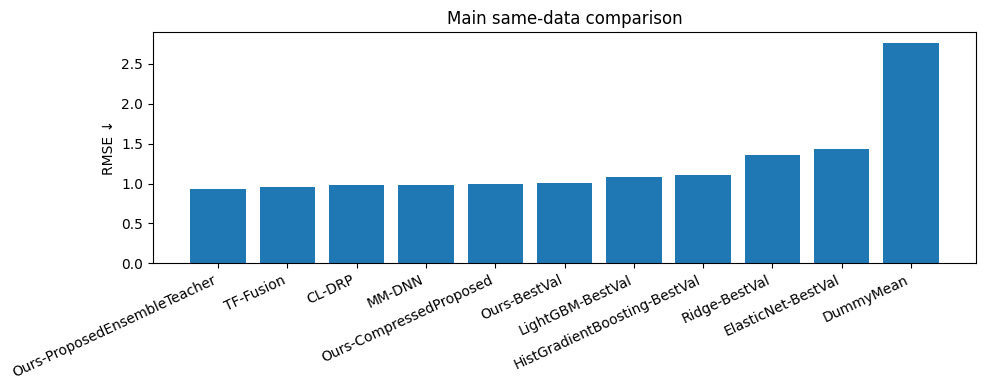

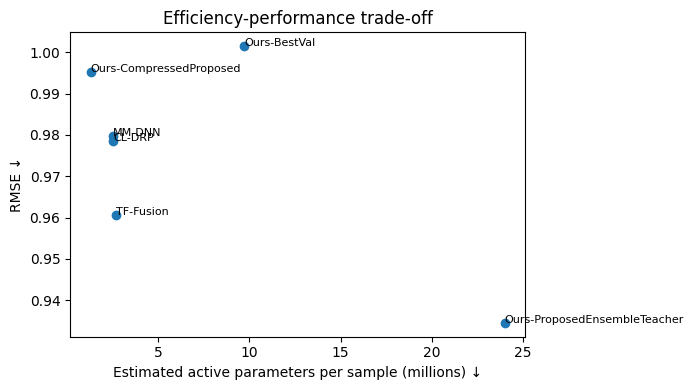

Best non-proposed baseline: TF-Fusion RMSE= 0.9605 R2= 0.8788
Best proposed accuracy row: Ours-ProposedEnsembleTeacher selected= BYOL+SparseMoE+CL+SparseMoE+BYOL+CL+SparseMoE+EE-adamw-lr0.0005 RMSE= 0.9345 R2= 0.8853
Deployment recommendation: use Ours-CompressedProposed when model size/time matter.
Compressed vs ensemble teacher RMSE gap: 0.0608
Estimated active model-size reduction vs ensemble teacher: 94.6 %
Supported result: proposed architecture improves over the best same-data non-proposed baseline on this split.


In [22]:
# Only sparse MoE-family models are eligible for the proposed architecture selection.
if len(ablation_runs) == 0:
    raise RuntimeError("No proposed ablation runs are available. Set CFG.RUN_PROPOSED_ABLATIONS=True for the full experiment.")

proposed_candidate_runs = [r for r in ablation_runs if "MoE" in r["name"]]
if len(proposed_candidate_runs) == 0:
    raise RuntimeError("No MoE-family proposed runs were found in ablation_runs.")

ranked_by_val = sorted(proposed_candidate_runs, key=lambda r: r["val_metrics"]["rmse"])
best_proposed_run = ranked_by_val[0]

best_proposed_row = {
    "model": "Ours-BestVal",
    "family": "proposed selected",
    "selected_model": best_proposed_run["name"],
    "teacher_model": np.nan,
    "optimizer": best_proposed_run.get("config", {}).get("optimizer", CFG.OPTIMIZER_NAME),
    "val_rmse": best_proposed_run["val_metrics"]["rmse"],
    **best_proposed_run["test_metrics"],
    **best_proposed_run.get("complexity", {}),
}

# Proposed-only validation-weighted ensemble.
# Important: this is accurate but heavy because it runs several trained proposed branches.
top_for_ensemble = ranked_by_val[:min(3, len(ranked_by_val))]
weights = np.array([1.0 / (r["val_metrics"]["rmse"] ** 2 + 1e-8) for r in top_for_ensemble], dtype="float64")
weights = weights / weights.sum()

def weighted_prediction_blend(runs, weights, split="test"):
    key = f"{split}_preds"
    out = np.zeros_like(runs[0][key], dtype="float64")
    for w, r in zip(weights, runs):
        out += float(w) * r[key]
    return out

val_ens = weighted_prediction_blend(top_for_ensemble, weights, split="val")
test_ens = weighted_prediction_blend(top_for_ensemble, weights, split="test")
val_ens_metrics, _ = extended_metrics(val_df, y_val, val_ens)
test_ens_metrics, _ = extended_metrics(test_df, y_test, test_ens)
ensemble_row = {
    "model": "Ours-ProposedEnsembleTeacher",
    "family": "proposed ensemble teacher",
    "selected_model": "+".join([r["name"] for r in top_for_ensemble]),
    "teacher_model": np.nan,
    "optimizer": np.nan,
    "val_rmse": val_ens_metrics["rmse"],
    **test_ens_metrics,
    "train_seconds": float(np.sum([r.get("complexity", {}).get("train_seconds", 0.0) for r in top_for_ensemble])),
    "epochs_trained": np.nan,
    "parameter_count": int(np.sum([r.get("complexity", {}).get("parameter_count", 0) for r in top_for_ensemble])),
    "active_parameter_count_est": int(np.sum([r.get("complexity", {}).get("active_parameter_count_est", 0) for r in top_for_ensemble])),
    "model_size_mb_est": float(np.sum([r.get("complexity", {}).get("model_size_mb_est", 0.0) for r in top_for_ensemble])),
    "active_model_size_mb_est": float(np.sum([r.get("complexity", {}).get("active_model_size_mb_est", 0.0) for r in top_for_ensemble])),
    "inference_ms_per_1k": float(np.sum([r.get("complexity", {}).get("inference_ms_per_1k", 0.0) for r in top_for_ensemble])),
    "mixed_precision": bool(getattr(CFG, "USE_MIXED_PRECISION", False) and CFG.DEVICE == "cuda"),
    "early_exit_rate_test": float(np.mean([r.get("complexity", {}).get("early_exit_rate_test", 0.0) for r in top_for_ensemble])),
}

# Backward-compatible alias used in older notes/tables.
model_predictions["Ours-ProposedEnsemble"] = test_ens
model_val_predictions["Ours-ProposedEnsemble"] = val_ens
model_predictions["Ours-ProposedEnsembleTeacher"] = test_ens
model_val_predictions["Ours-ProposedEnsembleTeacher"] = val_ens
model_routers["Ours-ProposedEnsemble"] = None
model_routers["Ours-ProposedEnsembleTeacher"] = None

# Knowledge distillation dataset and helpers.
class GDSCDistillDataset(GDSCDataset):
    def __init__(self, X_cell, X_drug, X_context, y, y_teacher, entities=None):
        super().__init__(X_cell, X_drug, X_context, y, entities)
        self.y_teacher = torch.tensor(y_teacher, dtype=torch.float32)

    def __getitem__(self, idx):
        item = super().__getitem__(idx)
        item["y_teacher"] = self.y_teacher[idx]
        return item


def make_distill_loader(Xc, Xd, Xctx, y, y_teacher, entities, shuffle=False, batch_size=None):
    return DataLoader(
        GDSCDistillDataset(Xc, Xd, Xctx, y, y_teacher, entities),
        batch_size=batch_size or CFG.BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(CFG.DEVICE == "cuda"),
    )


def make_student_model():
    return ProposedSSLCLMoE(
        CELL_DIM, DRUG_DIM, CONTEXT_DIM,
        entity_cardinalities=entity_cardinalities,
        ssl_encoder=None,
        use_ssl=False,
        use_moe=True,
        use_entity=True,
        use_early_exit=CFG.USE_EARLY_EXIT,
        early_exit_threshold=CFG.EARLY_EXIT_CONF_THRESHOLD,
        num_experts=CFG.STUDENT_NUM_EXPERTS,
        top_k=CFG.STUDENT_TOP_K,
        router_temperature=getattr(CFG, "ROUTER_TEMPERATURE", None),
        latent_dim=CFG.STUDENT_LATENT_DIM,
        hidden_dim=CFG.STUDENT_HIDDEN_DIM,
        dropout=CFG.DROPOUT,
    )


def train_student_from_teacher(name, teacher_name, teacher_train_preds, teacher_val_preds, teacher_test_preds, epochs):
    y_teacher_train_model = scale_y(teacher_train_preds)
    y_teacher_val_model = scale_y(teacher_val_preds)
    y_teacher_test_model = scale_y(teacher_test_preds)

    train_distill_loader = make_distill_loader(
        X_cell_train, X_drug_train, X_context_train, y_train_model, y_teacher_train_model, train_entities, shuffle=True
    )
    val_distill_loader = make_distill_loader(
        X_cell_val, X_drug_val, X_context_val, y_val_model, y_teacher_val_model, val_entities, shuffle=False
    )
    test_distill_loader = make_distill_loader(
        X_cell_test, X_drug_test, X_context_test, y_test_model, y_teacher_test_model, test_entities, shuffle=False
    )

    student_model = make_student_model()
    run = train_model(
        name, student_model,
        train_distill_loader, val_distill_loader, test_distill_loader,
        epochs=epochs,
        lr=CFG.LR,
        lr_ssl=0.0,
        cl_weight=0.0,
        lb_weight=CFG.LB_WEIGHT,
        freeze_ssl_epochs=0,
        optimizer_name=CFG.OPTIMIZER_NAME,
        distill_alpha=CFG.DISTILL_ALPHA,
        early_exit_weight=CFG.EARLY_EXIT_LOSS_WEIGHT,
    )
    run["config"] = {
        "use_ssl": False,
        "use_cl": False,
        "use_moe": True,
        "use_early_exit": CFG.USE_EARLY_EXIT,
        "optimizer": CFG.OPTIMIZER_NAME,
        "distilled_from": teacher_name,
        "distill_alpha": CFG.DISTILL_ALPHA,
        "note": "Student is compact. SSL/CL knowledge is inherited only if the teacher contains SSL/CL branches.",
    }
    model_runs[run["name"]] = run
    model_predictions[run["name"]] = run["test_preds"]
    model_val_predictions[run["name"]] = run["val_preds"]
    model_embeddings[run["name"]] = run["test_emb"]
    model_routers[run["name"]] = run["test_router"]
    return run

student_rows = []
distilled_student_run = None
compressed_student_run = None

if getattr(CFG, "RUN_DISTILLATION", True):
    train_eval_loader = make_loader(X_cell_train, X_drug_train, X_context_train, y_train_model, train_entities, shuffle=False)

    # Optional older single-teacher student. Disabled by default to save time.
    if getattr(CFG, "RUN_SINGLE_TEACHER_DISTILLATION", False):
        print("\nTraining single-teacher distilled student from:", best_proposed_run["name"])
        _, teacher_train_preds, _, _, _ = evaluate_model(best_proposed_run["model"], train_eval_loader, return_embeddings=False)
        distilled_student_run = train_student_from_teacher(
            "Ours-DistilledStudent",
            best_proposed_run["name"],
            teacher_train_preds,
            best_proposed_run["val_preds"],
            best_proposed_run["test_preds"],
            epochs=CFG.DISTILL_EPOCHS,
        )
        student_rows.append({
            "model": "Ours-DistilledStudent",
            "family": "proposed distilled student",
            "selected_model": distilled_student_run["name"],
            "teacher_model": best_proposed_run["name"],
            "distill_alpha": CFG.DISTILL_ALPHA,
            "optimizer": CFG.OPTIMIZER_NAME,
            "val_rmse": distilled_student_run["val_metrics"]["rmse"],
            **distilled_student_run["test_metrics"],
            **distilled_student_run.get("complexity", {}),
        })

    # Main efficiency correction: distill the full proposed ensemble teacher into one compact student.
    if getattr(CFG, "RUN_ENSEMBLE_DISTILLATION", True):
        print("\nTraining compressed proposed student from ensemble teacher:", ensemble_row["selected_model"])
        train_teacher_parts = []
        for r in top_for_ensemble:
            _, train_preds_r, _, _, _ = evaluate_model(r["model"], train_eval_loader, return_embeddings=False)
            train_teacher_parts.append(train_preds_r)
        train_teacher_parts = np.vstack(train_teacher_parts)
        train_ens = np.average(train_teacher_parts, axis=0, weights=weights)

        compressed_student_run = train_student_from_teacher(
            "Ours-CompressedProposed",
            "Ours-ProposedEnsembleTeacher",
            train_ens,
            val_ens,
            test_ens,
            epochs=getattr(CFG, "ENSEMBLE_DISTILL_EPOCHS", CFG.DISTILL_EPOCHS),
        )
        distilled_student_run = compressed_student_run  # backward-compatible variable used by save cells
        student_rows.append({
            "model": "Ours-CompressedProposed",
            "family": "proposed compressed deployment",
            "selected_model": compressed_student_run["name"],
            "teacher_model": "Ours-ProposedEnsembleTeacher",
            "distill_alpha": CFG.DISTILL_ALPHA,
            "optimizer": CFG.OPTIMIZER_NAME,
            "val_rmse": compressed_student_run["val_metrics"]["rmse"],
            **compressed_student_run["test_metrics"],
            **compressed_student_run.get("complexity", {}),
        })
else:
    print("Knowledge distillation disabled by CFG.RUN_DISTILLATION=False")

# Add student rows to ablation/results with explicit component flags.
for row in student_rows:
    ablation_like = {
        **row,
        "use_ssl": False,
        "use_cl": False,
        "use_moe": True,
        "use_early_exit": CFG.USE_EARLY_EXIT,
        "lr": CFG.LR,
    }
    ablation_results = pd.concat([ablation_results, pd.DataFrame([ablation_like])], ignore_index=True)

model_predictions["Ours-BestVal"] = best_proposed_run["test_preds"]
model_val_predictions["Ours-BestVal"] = best_proposed_run["val_preds"]
model_embeddings["Ours-BestVal"] = best_proposed_run["test_emb"]
model_routers["Ours-BestVal"] = best_proposed_run["test_router"]
model_runs["Ours-BestVal"] = best_proposed_run
model_runs["Ours-ProposedEnsembleTeacher"] = {"name": "Ours-ProposedEnsembleTeacher", "model": None, "test_preds": test_ens, "val_preds": val_ens, "test_router": None, "test_emb": None}

base_rows = classical_rows + literature_rows + [best_proposed_row, ensemble_row] + student_rows
main_results = pd.DataFrame(base_rows)
main_results = main_results.sort_values("rmse").reset_index(drop=True)
if len(ablation_results):
    ablation_results = ablation_results.sort_values("val_rmse").reset_index(drop=True)

ranking_cols = [c for c in [
    "model", "family", "selected_model", "teacher_model", "optimizer", "val_rmse", "rmse", "mae", "medae",
    "p90_abs_error", "r2", "explained_variance", "pearson", "spearman", "cell_spearman",
    "top3_drug_hit", "train_seconds", "epochs_trained", "parameter_count", "active_parameter_count_est",
    "model_size_mb_est", "active_model_size_mb_est", "inference_ms_per_1k", "mixed_precision", "early_exit_rate_test", "distill_alpha"
] if c in main_results.columns]

print("Main Q1-style same-data comparison")
display(main_results[ranking_cols])
print("\nAblation study")
display(ablation_results[[c for c in ranking_cols + ["use_ssl", "use_cl", "use_moe", "use_early_exit"] if c in ablation_results.columns]])

plot_df = main_results.sort_values("rmse").head(12)
plt.figure(figsize=(10, 4))
plt.bar(plot_df["model"], plot_df["rmse"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("RMSE ↓")
plt.title("Main same-data comparison")
plt.tight_layout()
plt.show()

if "active_parameter_count_est" in main_results.columns:
    eff_df = main_results.dropna(subset=["active_parameter_count_est", "rmse"]).copy()
    plt.figure(figsize=(7, 4))
    plt.scatter(eff_df["active_parameter_count_est"] / 1e6, eff_df["rmse"])
    for _, row in eff_df.iterrows():
        plt.text(row["active_parameter_count_est"] / 1e6, row["rmse"], str(row["model"]), fontsize=8)
    plt.xlabel("Estimated active parameters per sample (millions) ↓")
    plt.ylabel("RMSE ↓")
    plt.title("Efficiency-performance trade-off")
    plt.tight_layout()
    plt.show()

baseline_pool = main_results[~main_results["family"].astype(str).str.contains("proposed", case=False, na=False)]
best_baseline = baseline_pool.sort_values("rmse").iloc[0] if len(baseline_pool) else None
proposed_names_for_selection = ["Ours-ProposedEnsembleTeacher", "Ours-CompressedProposed", "Ours-BestVal", "Ours-DistilledStudent"]
best_proposed = main_results[main_results["model"].isin(proposed_names_for_selection)].sort_values("rmse").iloc[0]
if best_baseline is not None:
    print("Best non-proposed baseline:", best_baseline["model"], "RMSE=", round(best_baseline["rmse"], 4), "R2=", round(best_baseline["r2"], 4))
print("Best proposed accuracy row:", best_proposed["model"], "selected=", best_proposed.get("selected_model", ""), "RMSE=", round(best_proposed["rmse"], 4), "R2=", round(best_proposed["r2"], 4))

if "Ours-CompressedProposed" in set(main_results["model"]):
    compact = main_results[main_results["model"] == "Ours-CompressedProposed"].iloc[0]
    teacher = main_results[main_results["model"] == "Ours-ProposedEnsembleTeacher"].iloc[0]
    print("Deployment recommendation: use Ours-CompressedProposed when model size/time matter.")
    print("Compressed vs ensemble teacher RMSE gap:", round(float(compact["rmse"] - teacher["rmse"]), 4))
    if pd.notna(compact.get("active_model_size_mb_est", np.nan)) and pd.notna(teacher.get("active_model_size_mb_est", np.nan)):
        reduction = 100.0 * (1.0 - float(compact["active_model_size_mb_est"]) / max(float(teacher["active_model_size_mb_est"]), 1e-8))
        print("Estimated active model-size reduction vs ensemble teacher:", round(reduction, 2), "%")

if best_baseline is not None and best_proposed["rmse"] < best_baseline["rmse"]:
    print("Supported result: proposed architecture improves over the best same-data non-proposed baseline on this split.")
elif best_baseline is not None:
    print("Careful claim: proposed architecture is competitive, but it does not outperform the best same-data non-proposed baseline on this split.")


## 16. Interpretable results

This section analyzes predictions, feature-block contribution, MoE expert routing, early-exit behavior, and error patterns. These outputs are useful for a paper discussion section and for explaining which cancer/drug regions the model routes to different experts.


Interpreted model: Ours-CompressedProposed
Selected best single proposed run: BYOL+SparseMoE
{'mse': 0.9905863527398501, 'rmse': 0.9952820468288626, 'mae': 0.7309763535848688, 'medae': 0.5596720576286316, 'p90_abs_error': 1.5440747141838074, 'bias_mean_error': -0.00472777660324584, 'error_std': 0.9952708178522267, 'r2': 0.8698499102432324, 'explained_variance': 0.8698528469867968, 'norm_rmse': 0.3607632032417509, 'iqr_rmse': 0.3116248608998116, 'rrmse': 0.04633244273188302, 'pearson': 0.932957968692629, 'spearman': 0.9059960165275097, 'wi': 0.9650704740976269, 'lmc': 0.9320378210740178, 'cell_spearman': 0.8748985751749717, 'top3_drug_hit': 0.7890382626680424}


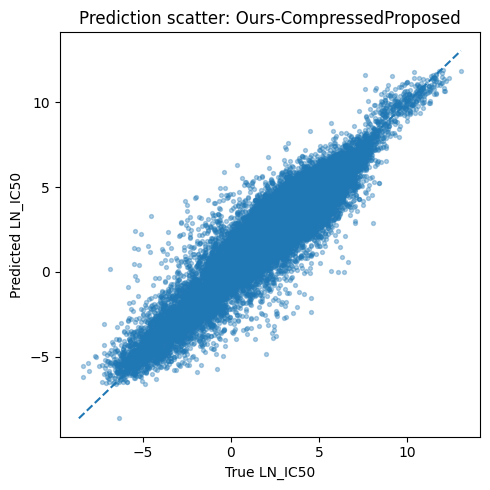

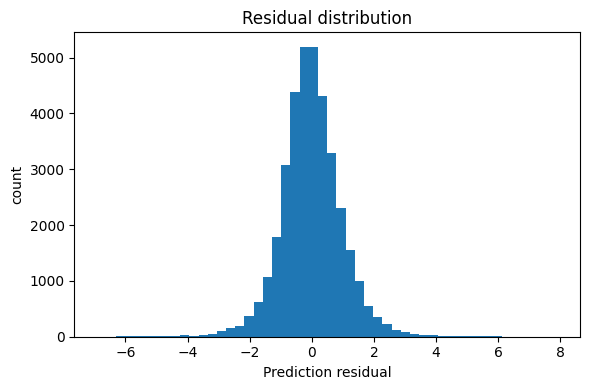

In [23]:
# Choose a model for interpretability.
# Prefer the compressed final deployment model if it exists; otherwise use the best single MoE run.
interp_name = "Ours-CompressedProposed" if "Ours-CompressedProposed" in model_predictions else "Ours-BestVal"
interp_run = model_runs.get(interp_name, best_proposed_run)
interp_preds = model_predictions[interp_name]
interp_metrics, interp_eval_df = extended_metrics(test_df, y_test, interp_preds)

# Defensive columns used by later interpretability cells.
interp_eval_df = interp_eval_df.copy()
interp_eval_df["error"] = interp_eval_df["pred"] - interp_eval_df["true"]
interp_eval_df["abs_error"] = np.abs(interp_eval_df["error"])
interp_eval_df["squared_error"] = interp_eval_df["error"] ** 2

# Attach useful metadata if extended_metrics did not preserve it.
for col in ["TCGA_DESC", "Cancer Type (matching TCGA label)", "DRUG_NAME", "DRUG_ID", "CELL_LINE_NAME", "COSMIC_ID"]:
    if col not in interp_eval_df.columns and col in test_df.columns and len(test_df) == len(interp_eval_df):
        interp_eval_df[col] = test_df[col].reset_index(drop=True).values

print("Interpreted model:", interp_name)
print("Selected best single proposed run:", best_proposed_run["name"])
print(interp_metrics)

plt.figure(figsize=(5, 5))
plt.scatter(interp_eval_df["true"], interp_eval_df["pred"], s=8, alpha=0.35)
lo = min(interp_eval_df["true"].min(), interp_eval_df["pred"].min())
hi = max(interp_eval_df["true"].max(), interp_eval_df["pred"].max())
plt.plot([lo, hi], [lo, hi], linestyle="--")
plt.xlabel("True LN_IC50")
plt.ylabel("Predicted LN_IC50")
plt.title(f"Prediction scatter: {interp_name}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(interp_eval_df["error"], bins=50)
plt.xlabel("Prediction residual")
plt.ylabel("count")
plt.title("Residual distribution")
plt.tight_layout()
plt.show()


,block,rmse_after_zeroing,delta_rmse
0,drug,2.381908,1.386626e+00
1,smiles_tfidf,2.364054,1.368772e+00
2,drug_meta,1.850547,8.552646e-01
3,cell,1.290821,2.955394e-01
4,context,1.182607,1.873246e-01
5,smiles_struct,0.995282,-3.305708e-10
6,rdkit_molecular,0.995282,-3.305708e-10


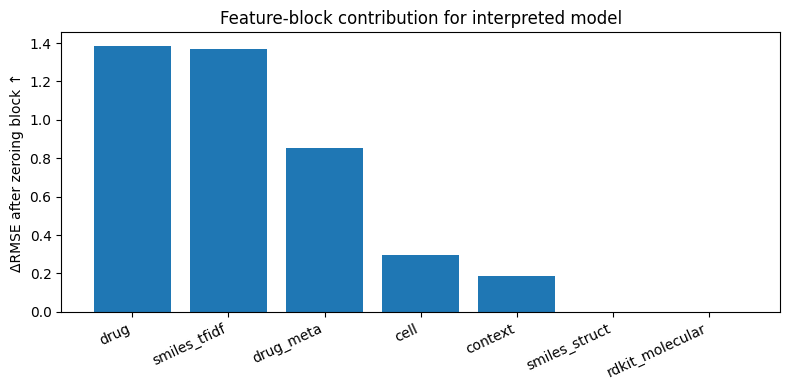

In [24]:
# Feature-block occlusion importance for the interpreted neural model.
# This requires an actual neural model object, so it is skipped for pure prediction ensembles.
def evaluate_arrays_with_model(run, Xc, Xd, Xctx, entities):
    loader = make_loader(Xc, Xd, Xctx, y_test_model, entities, shuffle=False, batch_size=CFG.BATCH_SIZE)
    metrics, preds, true, emb, router = evaluate_model(run["model"], loader)
    return metrics

block_importance = pd.DataFrame()
run_for_importance = interp_run if interp_run.get("model") is not None else best_proposed_run

if run_for_importance.get("model") is not None:
    base_rmse = run_for_importance["test_metrics"]["rmse"] if "test_metrics" in run_for_importance else interp_metrics["rmse"]
    importance_rows = []

    # Whole modality occlusion.
    for block in ["cell", "drug", "context"]:
        Xc, Xd, Xctx = X_cell_test.copy(), X_drug_test.copy(), X_context_test.copy()
        if block == "cell":
            Xc[:] = 0
        elif block == "drug":
            Xd[:] = 0
        elif block == "context":
            Xctx[:] = 0
        m = evaluate_arrays_with_model(run_for_importance, Xc, Xd, Xctx, test_entities)
        importance_rows.append({"block": block, "rmse_after_zeroing": m["rmse"], "delta_rmse": m["rmse"] - base_rmse})

    # Drug sub-block occlusion.
    for block, (a, b) in drug_slices.items():
        if b <= a:
            continue
        Xd = X_drug_test.copy()
        Xd[:, a:b] = 0
        m = evaluate_arrays_with_model(run_for_importance, X_cell_test, Xd, X_context_test, test_entities)
        importance_rows.append({"block": block, "rmse_after_zeroing": m["rmse"], "delta_rmse": m["rmse"] - base_rmse})

    block_importance = pd.DataFrame(importance_rows).sort_values("delta_rmse", ascending=False).reset_index(drop=True)
    display(block_importance)

    plt.figure(figsize=(8, 4))
    plt.bar(block_importance["block"], block_importance["delta_rmse"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("ΔRMSE after zeroing block ↑")
    plt.title("Feature-block contribution for interpreted model")
    plt.tight_layout()
    plt.show()
else:
    print("Feature-block occlusion skipped because the interpreted model has no neural model object.")


Early-exit rate on test set: 0.9912
Mean early-exit confidence: 0.8239


,expert,usage_rate_non_exited
0,0,0.247649
1,1,0.238245
2,2,0.379310
3,3,0.134796


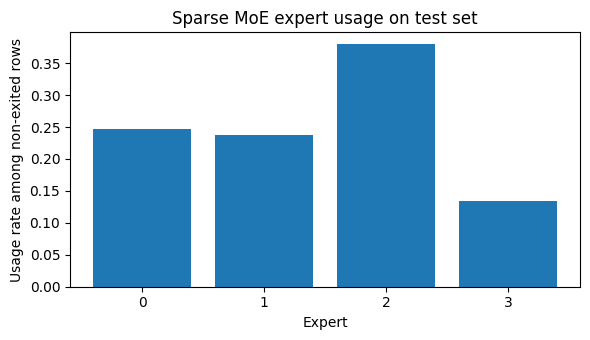

expert,0,1,2,3
TCGA_DESC,,,,
BRCA,0.250000,0.285714,0.321429,0.142857
COREAD,0.150000,0.150000,0.500000,0.200000
ESCA,0.000000,0.083333,0.833333,0.083333
GBM,0.153846,0.153846,0.461538,0.230769
KIRC,0.363636,0.181818,0.454545,0.000000
LUAD,0.172414,0.172414,0.310345,0.344828
NB,0.125000,0.312500,0.375000,0.187500
PAAD,0.466667,0.066667,0.333333,0.133333
SCLC,0.105263,0.473684,0.210526,0.210526


In [25]:
# MoE router and early-exit interpretability.
router = interp_run.get("test_router") if isinstance(interp_run, dict) else None
exit_mask = interp_run.get("test_exit_mask") if isinstance(interp_run, dict) else None

if exit_mask is not None and len(exit_mask) == len(interp_eval_df):
    print("Early-exit rate on test set:", round(float(np.mean(exit_mask)), 4))
    conf = interp_run.get("test_early_confidence", np.array([np.nan]))
    if np.isfinite(conf).any():
        print("Mean early-exit confidence:", round(float(np.nanmean(conf)), 4))

if router is not None and len(router) == len(interp_eval_df):
    router = np.asarray(router)
    expert_id = router.argmax(axis=1)
    router_df = test_df.copy().reset_index(drop=True)
    router_df["expert"] = expert_id
    router_df["router_confidence"] = router.max(axis=1)
    if exit_mask is not None and len(exit_mask) == len(router_df):
        router_df["early_exit"] = np.asarray(exit_mask).astype(bool)
        routed_df = router_df[~router_df["early_exit"]].copy()
    else:
        routed_df = router_df.copy()

    if len(routed_df):
        usage = routed_df["expert"].value_counts(normalize=True).sort_index().rename("usage_rate_non_exited").reset_index().rename(columns={"index": "expert"})
        display(usage)

        plt.figure(figsize=(6, 3.5))
        plt.bar(usage["expert"].astype(str), usage["usage_rate_non_exited"])
        plt.xlabel("Expert")
        plt.ylabel("Usage rate among non-exited rows")
        plt.title("Sparse MoE expert usage on test set")
        plt.tight_layout()
        plt.show()

        cancer_col = "TCGA_DESC" if "TCGA_DESC" in router_df.columns else None
        if cancer_col is not None:
            top_cancers = routed_df[cancer_col].value_counts().head(12).index
            cancer_expert = pd.crosstab(
                routed_df.loc[routed_df[cancer_col].isin(top_cancers), cancer_col],
                routed_df.loc[routed_df[cancer_col].isin(top_cancers), "expert"],
                normalize="index",
            )
            display(cancer_expert)
    else:
        print("All rows exited early, so there are no non-exited rows for router-usage analysis.")
else:
    print("Interpreted model has no valid router output, or router length does not match test rows.")


In [26]:
# Early-exit quality check: compare exited vs non-exited errors.
exit_mask = interp_run.get("test_exit_mask") if isinstance(interp_run, dict) else None

if "abs_error" not in interp_eval_df.columns:
    interp_eval_df["error"] = interp_eval_df["pred"] - interp_eval_df["true"]
    interp_eval_df["abs_error"] = np.abs(interp_eval_df["error"])
if "squared_error" not in interp_eval_df.columns:
    interp_eval_df["squared_error"] = interp_eval_df["error"] ** 2

if exit_mask is not None and len(exit_mask) == len(interp_eval_df):
    exit_eval = interp_eval_df.copy()
    exit_eval["early_exit"] = np.asarray(exit_mask).astype(bool)
    exit_summary = (
        exit_eval
        .groupby("early_exit", dropna=False)
        .agg(
            n=("abs_error", "size"),
            mean_abs_error=("abs_error", "mean"),
            median_abs_error=("abs_error", "median"),
            rmse=("squared_error", lambda x: float(np.sqrt(np.mean(x)))),
            mean_pred_ln_ic50=("pred", "mean"),
            mean_true_ln_ic50=("true", "mean"),
        )
        .reset_index()
    )
    exit_summary["early_exit"] = exit_summary["early_exit"].map({True: "exited_early", False: "used_full_moe"})
    display(exit_summary)
else:
    print("No valid early-exit mask available for this interpreted model.")


,early_exit,n,mean_abs_error,median_abs_error,rmse,mean_pred_ln_ic50,mean_true_ln_ic50
0,used_full_moe,319,1.464720,1.319811,1.777593,-1.955262,-2.01107
1,exited_early,35987,0.724472,0.555495,0.985575,2.857126,2.86239


In [27]:
# Group-level error analysis.
group_col = "TCGA_DESC" if "TCGA_DESC" in interp_eval_df.columns else (
    "Cancer Type (matching TCGA label)" if "Cancer Type (matching TCGA label)" in interp_eval_df.columns else None
)
if group_col is not None:
    group_perf = []
    for g, part in interp_eval_df.groupby(group_col):
        if len(part) < 50:
            continue
        m = regression_metrics(part["true"], part["pred"])
        group_perf.append({"group": g, "n": len(part), "rmse": m["rmse"], "mae": m["mae"], "r2": m["r2"], "pearson": m["pearson"]})
    group_perf = pd.DataFrame(group_perf)
    if len(group_perf):
        group_perf = group_perf.sort_values("rmse").reset_index(drop=True)
        display(group_perf.head(20))
        display(group_perf.tail(20))
    else:
        print("No cancer group has at least 50 held-out rows.")
else:
    print("Cancer-type column not found for group-level analysis.")


,group,n,rmse,mae,r2,pearson
0,CLL,77,0.771280,0.621852,0.923904,0.961339
1,ACC,52,0.835157,0.592602,0.909467,0.954945
2,UCEC,368,0.859389,0.650273,0.895755,0.948452
3,BLCA,659,0.889064,0.651545,0.871572,0.934539
4,CESC,582,0.889699,0.677942,0.872984,0.934552
5,ALL,1001,0.893231,0.652684,0.893419,0.945949
6,MB,164,0.948867,0.653114,0.857953,0.927979
7,UNCLASSIFIED,6898,0.952933,0.698817,0.880335,0.938459
8,LCML,393,0.954940,0.701756,0.882091,0.939930
9,DLBC,1223,0.957626,0.686906,0.882176,0.939340


,group,n,rmse,mae,r2,pearson
12,MESO,784,0.969605,0.737624,0.859985,0.927514
13,THCA,578,0.980054,0.749719,0.877851,0.937540
14,PAAD,1121,0.980733,0.759768,0.874983,0.935724
15,SCLC,2022,0.982354,0.727925,0.867957,0.932625
16,KIRC,1125,0.985446,0.741110,0.864524,0.930917
17,NB,1158,0.989281,0.737714,0.861863,0.928539
18,SKCM,1879,0.990112,0.737716,0.860203,0.928700
19,LGG,502,1.001701,0.758118,0.895608,0.946720
20,ESCA,1374,1.002824,0.737544,0.860597,0.928297
21,LIHC,626,1.013843,0.751202,0.829474,0.912585


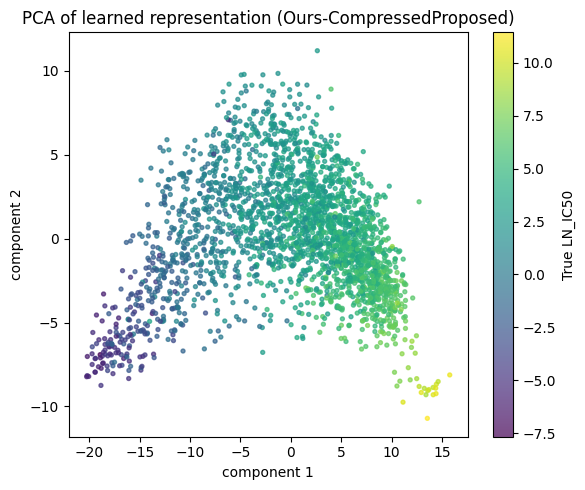

In [28]:
# Representation visualization. This is for interpretation only, not model feature reduction.
emb = model_embeddings.get(interp_name)
if emb is None:
    emb = model_embeddings.get("Ours-BestVal")

if emb is not None:
    n = min(len(emb), CFG.MAX_VIS_POINTS)
    rng = np.random.default_rng(CFG.SEED)
    idx = rng.choice(len(emb), size=n, replace=False) if len(emb) > n else np.arange(len(emb))
    Z = emb[idx]
    y_color = y_test[idx]

    method = CFG.EMBED_VIS_METHOD.lower()
    if method == "umap":
        try:
            import umap
            reducer = umap.UMAP(n_components=2, random_state=CFG.SEED)
            Z2 = reducer.fit_transform(Z)
            title = "UMAP of learned representation"
        except Exception as e:
            print("UMAP unavailable; falling back to PCA.", e)
            Z2 = PCA(n_components=2, random_state=CFG.SEED).fit_transform(Z)
            title = "PCA of learned representation"
    elif method == "tsne":
        from sklearn.manifold import TSNE
        Z2 = TSNE(n_components=2, random_state=CFG.SEED, init="pca", learning_rate="auto").fit_transform(Z)
        title = "t-SNE of learned representation"
    else:
        Z2 = PCA(n_components=2, random_state=CFG.SEED).fit_transform(Z)
        title = "PCA of learned representation"

    plt.figure(figsize=(6, 5))
    sc = plt.scatter(Z2[:, 0], Z2[:, 1], c=y_color, s=8, alpha=0.7)
    plt.colorbar(sc, label="True LN_IC50")
    plt.title(title + f" ({interp_name})")
    plt.xlabel("component 1")
    plt.ylabel("component 2")
    plt.tight_layout()
    plt.show()
else:
    print("No embeddings stored for visualization.")


## 17. Personalized medicine hypothesis tables

These tables summarize held-out predictions by cancer type and drug. They are intended for interpretation and hypothesis generation, not clinical use.


In [29]:
# Predicted top-sensitive drugs per cancer type on held-out rows.
# Lower predicted LN_IC50 means stronger predicted sensitivity.
drug_eval_df = interp_eval_df.copy()

if "abs_error" not in drug_eval_df.columns:
    drug_eval_df["error"] = drug_eval_df["pred"] - drug_eval_df["true"]
    drug_eval_df["abs_error"] = np.abs(drug_eval_df["error"])

# Attach metadata if missing.
for col in ["TCGA_DESC", "Cancer Type (matching TCGA label)", "DRUG_NAME", "DRUG_ID"]:
    if col not in drug_eval_df.columns and col in test_df.columns and len(test_df) == len(drug_eval_df):
        drug_eval_df[col] = test_df[col].reset_index(drop=True).values

cancer_col = "TCGA_DESC" if "TCGA_DESC" in drug_eval_df.columns else (
    "Cancer Type (matching TCGA label)" if "Cancer Type (matching TCGA label)" in drug_eval_df.columns else None
)
drug_col = "DRUG_NAME" if "DRUG_NAME" in drug_eval_df.columns else (
    "DRUG_ID" if "DRUG_ID" in drug_eval_df.columns else None
)

if cancer_col is not None and drug_col is not None:
    top_sensitive_by_cancer = (
        drug_eval_df
        .groupby([cancer_col, drug_col])
        .agg(
            n=("pred", "size"),
            mean_pred_ln_ic50=("pred", "mean"),
            mean_true_ln_ic50=("true", "mean"),
            mean_abs_error=("abs_error", "mean"),
        )
        .reset_index()
    )
    # Reduce noisy one-row pairs when possible.
    filtered = top_sensitive_by_cancer[top_sensitive_by_cancer["n"] >= 3].copy()
    if len(filtered) == 0:
        filtered = top_sensitive_by_cancer.copy()

    top_sensitive_by_cancer = (
        filtered
        .sort_values([cancer_col, "mean_pred_ln_ic50", "mean_abs_error"], ascending=[True, True, True])
        .groupby(cancer_col)
        .head(5)
        .reset_index(drop=True)
    )
    display(top_sensitive_by_cancer.head(100))
else:
    top_sensitive_by_cancer = pd.DataFrame()
    print("Cancer or drug column was not found, so top-sensitive drug table was skipped.")
    print("Available columns:", list(drug_eval_df.columns))

# Optional expert-drug summary for MoE interpretation.
router = interp_run.get("test_router") if isinstance(interp_run, dict) else None
if router is not None and cancer_col is not None and drug_col is not None:
    router = np.asarray(router)
    if len(router) == len(drug_eval_df):
        expert_df = drug_eval_df.copy()
        expert_df["expert"] = router.argmax(axis=1)
        expert_drug_summary = (
            expert_df
            .groupby(["expert", cancer_col, drug_col])
            .agg(
                n=("pred", "size"),
                mean_pred_ln_ic50=("pred", "mean"),
                mean_true_ln_ic50=("true", "mean"),
                mean_abs_error=("abs_error", "mean"),
            )
            .reset_index()
        )
        # Prefer less noisy rows, but keep all if filtering removes everything.
        filtered_expert = expert_drug_summary[expert_drug_summary["n"] >= 3].copy()
        if len(filtered_expert) == 0:
            filtered_expert = expert_drug_summary.copy()
        expert_drug_summary = (
            filtered_expert
            .sort_values(["expert", cancer_col, "mean_pred_ln_ic50", "mean_abs_error"], ascending=[True, True, True, True])
            .groupby(["expert", cancer_col])
            .head(3)
            .reset_index(drop=True)
        )
        display(expert_drug_summary.head(100))
    else:
        expert_drug_summary = pd.DataFrame()
        print(f"Router length mismatch: router={len(router)}, rows={len(drug_eval_df)}. Expert-drug summary skipped.")
else:
    expert_drug_summary = pd.DataFrame()


,TCGA_DESC,DRUG_NAME,n,mean_pred_ln_ic50,mean_true_ln_ic50,mean_abs_error
0,ALL,SN-38,4,-5.968226,-6.380192,0.576558
1,ALL,Romidepsin,4,-5.572960,-5.420388,1.397172
2,ALL,Vinblastine,3,-5.425016,-5.084085,0.830974
3,ALL,Bortezomib,7,-5.323003,-5.440608,0.423636
4,ALL,Docetaxel,9,-5.174996,-5.085653,0.535369
...,...,...,...,...,...,...
95,NB,Bortezomib,6,-5.054482,-4.850145,0.560143
96,NB,Docetaxel,7,-4.687803,-4.873982,1.055828
97,NB,SN-38,3,-4.484293,-4.773571,1.008850
98,NB,Dactinomycin,6,-4.318811,-4.180560,1.203462


,expert,TCGA_DESC,DRUG_NAME,n,mean_pred_ln_ic50,mean_true_ln_ic50,mean_abs_error
0,0,ALL,SN-38,4,-5.968226,-6.380192,0.576558
1,0,ALL,Romidepsin,4,-5.572960,-5.420388,1.397172
2,0,ALL,Vinblastine,3,-5.425016,-5.084085,0.830974
3,0,BLCA,Sepantronium bromide,3,-5.187586,-2.206391,2.981195
4,0,BLCA,Camptothecin,4,-2.675917,-3.122893,0.459817
...,...,...,...,...,...,...,...
95,2,COREAD,Dactinomycin,8,-3.305577,-3.173460,0.956178
96,2,ESCA,Dactinomycin,9,-3.530678,-3.661854,1.451841
97,2,GBM,Dactinomycin,6,-2.239506,-3.418332,1.603856
98,2,HNSC,Dactinomycin,3,-4.141638,-4.318361,1.091951


## 17. Save outputs

In [30]:
os.makedirs(CFG.WORK_DIR, exist_ok=True)
main_results.to_csv(os.path.join(CFG.WORK_DIR, "paper_ready_main_comparison.csv"), index=False)
classical_results.to_csv(os.path.join(CFG.WORK_DIR, "fair_same_data_baselines.csv"), index=False)
literature_results.to_csv(os.path.join(CFG.WORK_DIR, "neural_literature_aligned_baselines.csv"), index=False)
ablation_results.to_csv(os.path.join(CFG.WORK_DIR, "ablation_ssl_cl_moe.csv"), index=False)
feature_reduction_summary.to_csv(os.path.join(CFG.WORK_DIR, "feature_reduction_summary.csv"), index=False)
if "block_importance" in globals() and isinstance(block_importance, pd.DataFrame):
    block_importance.to_csv(os.path.join(CFG.WORK_DIR, "feature_block_importance.csv"), index=False)
if "interp_eval_df" in globals() and isinstance(interp_eval_df, pd.DataFrame):
    interp_eval_df.to_csv(os.path.join(CFG.WORK_DIR, "interpreted_model_predictions.csv"), index=False)
if "top_sensitive_by_cancer" in globals() and isinstance(top_sensitive_by_cancer, pd.DataFrame) and len(top_sensitive_by_cancer):
    top_sensitive_by_cancer.to_csv(os.path.join(CFG.WORK_DIR, "top_sensitive_drugs_by_cancer_type.csv"), index=False)
if "expert_drug_summary" in globals() and isinstance(expert_drug_summary, pd.DataFrame) and len(expert_drug_summary):
    expert_drug_summary.to_csv(os.path.join(CFG.WORK_DIR, "moe_expert_drug_summary.csv"), index=False)
if "distilled_student_run" in globals() and distilled_student_run is not None:
    distilled_student_run["history"].to_csv(os.path.join(CFG.WORK_DIR, "distilled_student_history.csv"), index=False)
if "compressed_student_run" in globals() and compressed_student_run is not None:
    compressed_student_run["history"].to_csv(os.path.join(CFG.WORK_DIR, "compressed_proposed_student_history.csv"), index=False)
if "ssl_history" in globals() and isinstance(ssl_history, pd.DataFrame):
    ssl_history.to_csv(os.path.join(CFG.WORK_DIR, "ssl_pretraining_history.csv"), index=False)

# Compact model-rank sheet for paper tables.
ranking_cols = [c for c in [
    "model", "family", "selected_model", "teacher_model", "val_rmse", "rmse", "mae", "medae", "p90_abs_error",
    "r2", "explained_variance", "pearson", "spearman", "cell_spearman", "top3_drug_hit",
    "train_seconds", "parameter_count", "active_parameter_count_est", "model_size_mb_est", "active_model_size_mb_est",
    "inference_ms_per_1k", "mixed_precision", "early_exit_rate_test", "distill_alpha"
] if c in main_results.columns]
main_results[ranking_cols].to_csv(os.path.join(CFG.WORK_DIR, "paper_ready_model_ranking.csv"), index=False)

print("Saved outputs to", CFG.WORK_DIR)
print("Recommended main table file: paper_ready_model_ranking.csv")
print("Recommended ablation table file: ablation_ssl_cl_moe.csv")

if "best_proposed_run" in globals() and best_proposed_run.get("model") is not None:
    torch.save(best_proposed_run["model"].state_dict(), os.path.join(CFG.WORK_DIR, "ours_bestval_state_dict.pt"))
if "compressed_student_run" in globals() and compressed_student_run is not None:
    torch.save(compressed_student_run["model"].state_dict(), os.path.join(CFG.WORK_DIR, "ours_compressed_proposed_state_dict.pt"))
elif "distilled_student_run" in globals() and distilled_student_run is not None:
    torch.save(distilled_student_run["model"].state_dict(), os.path.join(CFG.WORK_DIR, "ours_distilled_student_state_dict.pt"))

print("Selected best single proposed model:", best_proposed_run["name"])
if "compressed_student_run" in globals() and compressed_student_run is not None:
    print("Recommended deployment model: Ours-CompressedProposed")
else:
    print("Recommended deployment model: Ours-BestVal or best available compact model in paper_ready_model_ranking.csv")


Saved outputs to /kaggle/working/gdsc_q1_final_moe_ssl_cl
Recommended main table file: paper_ready_model_ranking.csv
Recommended ablation table file: ablation_ssl_cl_moe.csv
Selected best single proposed model: BYOL+SparseMoE
Recommended deployment model: Ours-CompressedProposed
